# AT2025aico

## 1. Load the data

In [1]:
# Load the data
from ezphot.utils import DataBrowser
dbrowser = DataBrowser('scidata')
dbrowser.objname = 'AT2025aico'
target_imgset_all = dbrowser.search('*com.fits', return_type = 'science')

'mocpy' is a mandatory dependency for MOCServer. You can install it with 'pip install mocpy'.
[INFO] Found 184 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/AT2025aico/*/*/*com.fits'


Loading Science Images: 100%|██████████| 184/184 [00:01<00:00, 136.80it/s]


In [2]:
target_imgset_all.df

Extracting info: 100%|██████████| 184/184 [00:02<00:00, 63.37it/s]


,image_id,path,filter,exptime,obsdate,observatory,telname,objname,seeing,depth,ra,dec,fov_ra,fov_dec
0,0,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m850,300.0,2025-12-28T07:10:45.000,7DT,7DT08,AT2025aico,1.914979,16.597911,11:29:16.32,20:35:08.52,1.431,0.954
1,1,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m850,300.0,2025-12-25T07:22:25.000,7DT,7DT08,AT2025aico,1.901496,17.004409,11:29:16.32,20:35:08.52,1.431,0.954
2,2,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m850,300.0,2025-12-26T07:11:44.000,7DT,7DT08,AT2025aico,2.398569,16.693964,11:29:16.32,20:35:08.52,1.431,0.954
3,3,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m850,300.0,2025-12-30T07:00:25.333,7DT,7DT08,AT2025aico,1.820805,17.168935,11:29:16.32,20:35:08.52,1.431,0.954
4,4,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m850,300.0,2026-01-02T08:16:23.000,7DT,7DT08,AT2025aico,1.777632,17.204158,11:29:16.32,20:35:08.52,1.431,0.954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,179,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m550,300.0,2025-12-30T07:05:54.333,7DT,7DT04,AT2025aico,2.219093,19.208600,11:29:16.32,20:35:08.52,1.431,0.954
180,180,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m550,300.0,2025-12-28T07:16:16.333,7DT,7DT04,AT2025aico,1.974205,19.063907,11:29:16.32,20:35:08.52,1.431,0.954
181,181,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m550,300.0,2025-12-27T07:17:11.333,7DT,7DT04,AT2025aico,1.942383,19.090580,11:29:16.32,20:35:08.52,1.431,0.954
182,182,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m550,300.0,2026-01-03T06:44:02.000,7DT,7DT04,AT2025aico,1.937338,18.073337,11:29:16.32,20:35:08.52,1.431,0.954


In [3]:
target_img = target_imgset_all.target_images[0]

(<Figure size 800x600 with 2 Axes>,
 <WCSAxes: title={'center': 'coadd_scaled_subbkg_7DT08_20251228_071230_AT2025aico_m850_1x1_100.0s_0002.com.fits'}>)

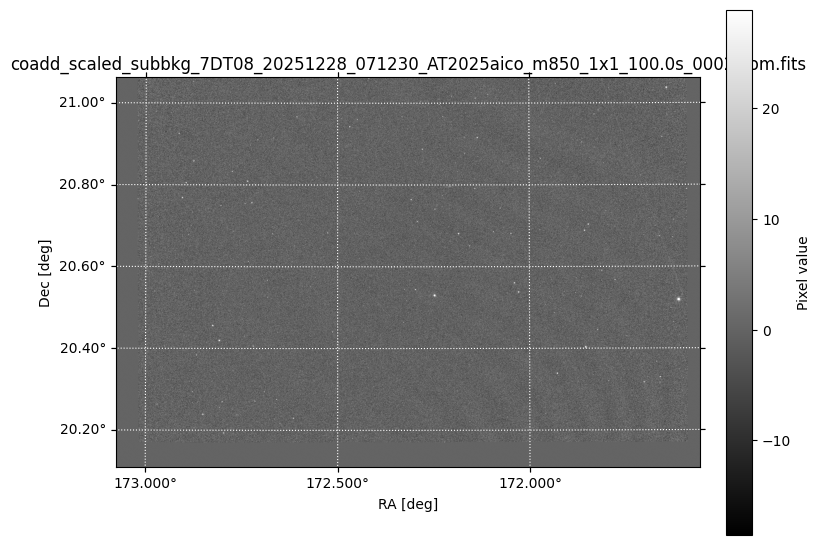

In [ ]:
target_img.show(coord_type = 'coord', close_fig = False)

## 2. Load the alert information

In [4]:
from bridge.alertmonitor import AlertProcessor
from bridge.objects import Alert
from bridge.connector import SQLConnector
connector = SQLConnector()
status_tbl = connector.get_data('transient_status')
row = status_tbl[status_tbl['objname'] == 'AT2025aico'][0]
alert_instance = Alert(**row)
target_ra = alert_instance.ra
target_dec = alert_instance.dec
alert_instance
from bridge.alertquerier import TNSQuerier
tnsquerier = TNSQuerier()
tns_info, tns_photometry, tns_spectra = tnsquerier.query_object(
    objname = '2025aico',
    with_photometry = True,
    with_spectra = True,
    save = True
)
from astropy.time import Time
tns_photometry['obsdate'] = Time(tns_photometry['jd'], format = 'jd').isot
tns_photometry['mjd'] = Time(tns_photometry['jd'], format = 'jd').mjd

Metadata saved to:  /home/hhchoi1022/bridge/alert/tns/2025aico/2025aico_meta_TNS.json
Number of photometry points:  9
Photometry table saved to:  /home/hhchoi1022/bridge/alert/tns/2025aico/2025aico_photometry_TNS.csv
Number of spectra:  3
File downloaded to:  /home/hhchoi1022/bridge/alert/tns/2025aico/TNS/tns_2025aico_2461057.04017361_MMT_BINOSPEC_ZTF.ascii
File downloaded to:  /home/hhchoi1022/bridge/alert/tns/2025aico/TNS/tns_2025aico_2025-12-25_14-57-51.5_Gemini-N_GMOS_PASSTA.txt
File downloaded to:  /home/hhchoi1022/bridge/alert/tns/2025aico/TNS/tns_2025aico_2025-12-25_14-57-51.5_Gemini-N_GMOS_PASSTA.fits
File downloaded to:  /home/hhchoi1022/bridge/alert/tns/2025aico/TNS/tns_2025aico_2025-12-25_08-03-14_SOAR_Goodman_None.txt
Spectroscopy table saved to:  /home/hhchoi1022/bridge/alert/tns/2025aico/2025aico_spectroscopy_TNS.csv


In [ ]:
tns_photometry

jd,mag,magerr,limmag,is_upper_limit,filter,mag_system,instrument,telescope,exptime,observer,remarks,objname,ra,dec,obsdate,mjd
float64,float64,float64,float64,bool,str10,str5,str8,str9,object,object,str21,str8,float64,float64,str23,float64
2460373.43668,nan,nan,21.93,True,Clear-,ABMag,LAST-Cam,LAST,400,None,[Last non detection],2025aico,172.3181846,20.585629,2024-03-03T22:28:49.152,60372.93667999981
2461029.69304,nan,nan,20.01,True,wide-ATLAS,ABMag,ATLAS-05,ATLAS-TDO,30,Robot,[Last non detection],2025aico,172.3181846,20.585629,2025-12-20T04:37:58.656,61029.19303999981
2461032.0285301,nan,nan,20.1973,True,r-ZTF,ABMag,ZTF-Cam,P48,None,None,[Last non detection],2025aico,172.3181846,20.585629,2025-12-22T12:41:05.001,61031.528530099895
2461032.681175,nan,nan,20.3,True,L-GOTO,ABMag,GOTO-1,GOTO-N,180,None,[Last non detection],2025aico,172.3181846,20.585629,2025-12-23T04:20:53.520,61032.181175000034
2461033.702066,16.86,0.01,nan,False,L-GOTO,ABMag,GOTO-1,GOTO-N,180,None,,2025aico,172.3181846,20.585629,2025-12-24T04:50:58.502,61033.202066000085
2461035.64925,17.407,0.028,19.96,False,wide-ATLAS,ABMag,ATLAS-05,ATLAS-TDO,30,Robot,,2025aico,172.3181846,20.585629,2025-12-26T03:34:55.200,61035.149249999784
2461037.306,17.69,0.01,nan,False,r-WFST,ABMag,WFST-WFC,WFST,30,None,,2025aico,172.3181846,20.585629,2025-12-27T19:20:38.400,61036.805999999866
2461038.9257292,17.778,0.0707011,nan,False,g-ZTF,ABMag,ZTF-Cam,P48,None,None,,2025aico,172.3181846,20.585629,2025-12-29T10:13:03.003,61038.42572919978
2461058.59353,16.21,nan,nan,False,Clear-,ABMag,LAST-Cam,LAST,380,None,,2025aico,172.3181846,20.585629,2026-01-18T02:14:40.992,61058.09353000019


## Compare lightcurve with TNS result

In [ ]:
target_imgset_all.select_images(filter = 'g')
target_imglist_g = target_imgset_all.target_images

### 1. Compare with source extractor photometry

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def process_single_image(args):
    idx, target_img = args
    try:
        target_catalog = target_img.photometry_sex(
            target_bkg=target_img.bkgmap,
            target_bkgrms=target_img.bkgrms,
            visualize=False,
            verbose=False,
            aperture_diameter_arcsec=[5, 7, 10],
            aperture_diameter_seeing=[3.5, 4.5],
            annulus_width_arcsec=5
        )

        target_img, target_catalog, _, _ = target_img.photometric_calibration(
            target_catalog,
            mag_lower=12,
            mag_upper=17.5,
            visualize=False,
            verbose=False
        )

        target_catalog.select_sources(target_ra, target_dec)
        return idx, target_catalog

    except Exception as e:
        print(f"[ERROR] Image {idx} failed: {e}")
        return idx, None


n_workers = min(len(target_imglist_g), 8)

with ThreadPoolExecutor(max_workers=n_workers) as executor:
    futures = [executor.submit(process_single_image, (i, img)) 
               for i, img in enumerate(target_imglist_g)]
    
    # Collect results in original order
    results = [None] * len(target_imglist_g)
    for future in as_completed(futures):
        idx, catalog = future.result()
        results[idx] = catalog
        print(f"[{sum(r is not None for r in results)}/{len(target_imglist_g)}] done")

target_cataloglist_g = [cat for cat in results if cat is not None]

[1/8] done
[2/8] done
[3/8] done
[4/8] done
[5/8] done
[6/8] done
[7/8] done
[8/8] done


In [ ]:
from ezphot.dataobjects import LightCurve, CatalogSet
lc = LightCurve(CatalogSet(target_cataloglist_g))

Merging catalogs: 100%|██████████| 7/7 [00:00<00:00, 138.14it/s]


Matched 1 sources out of 1 input positions.


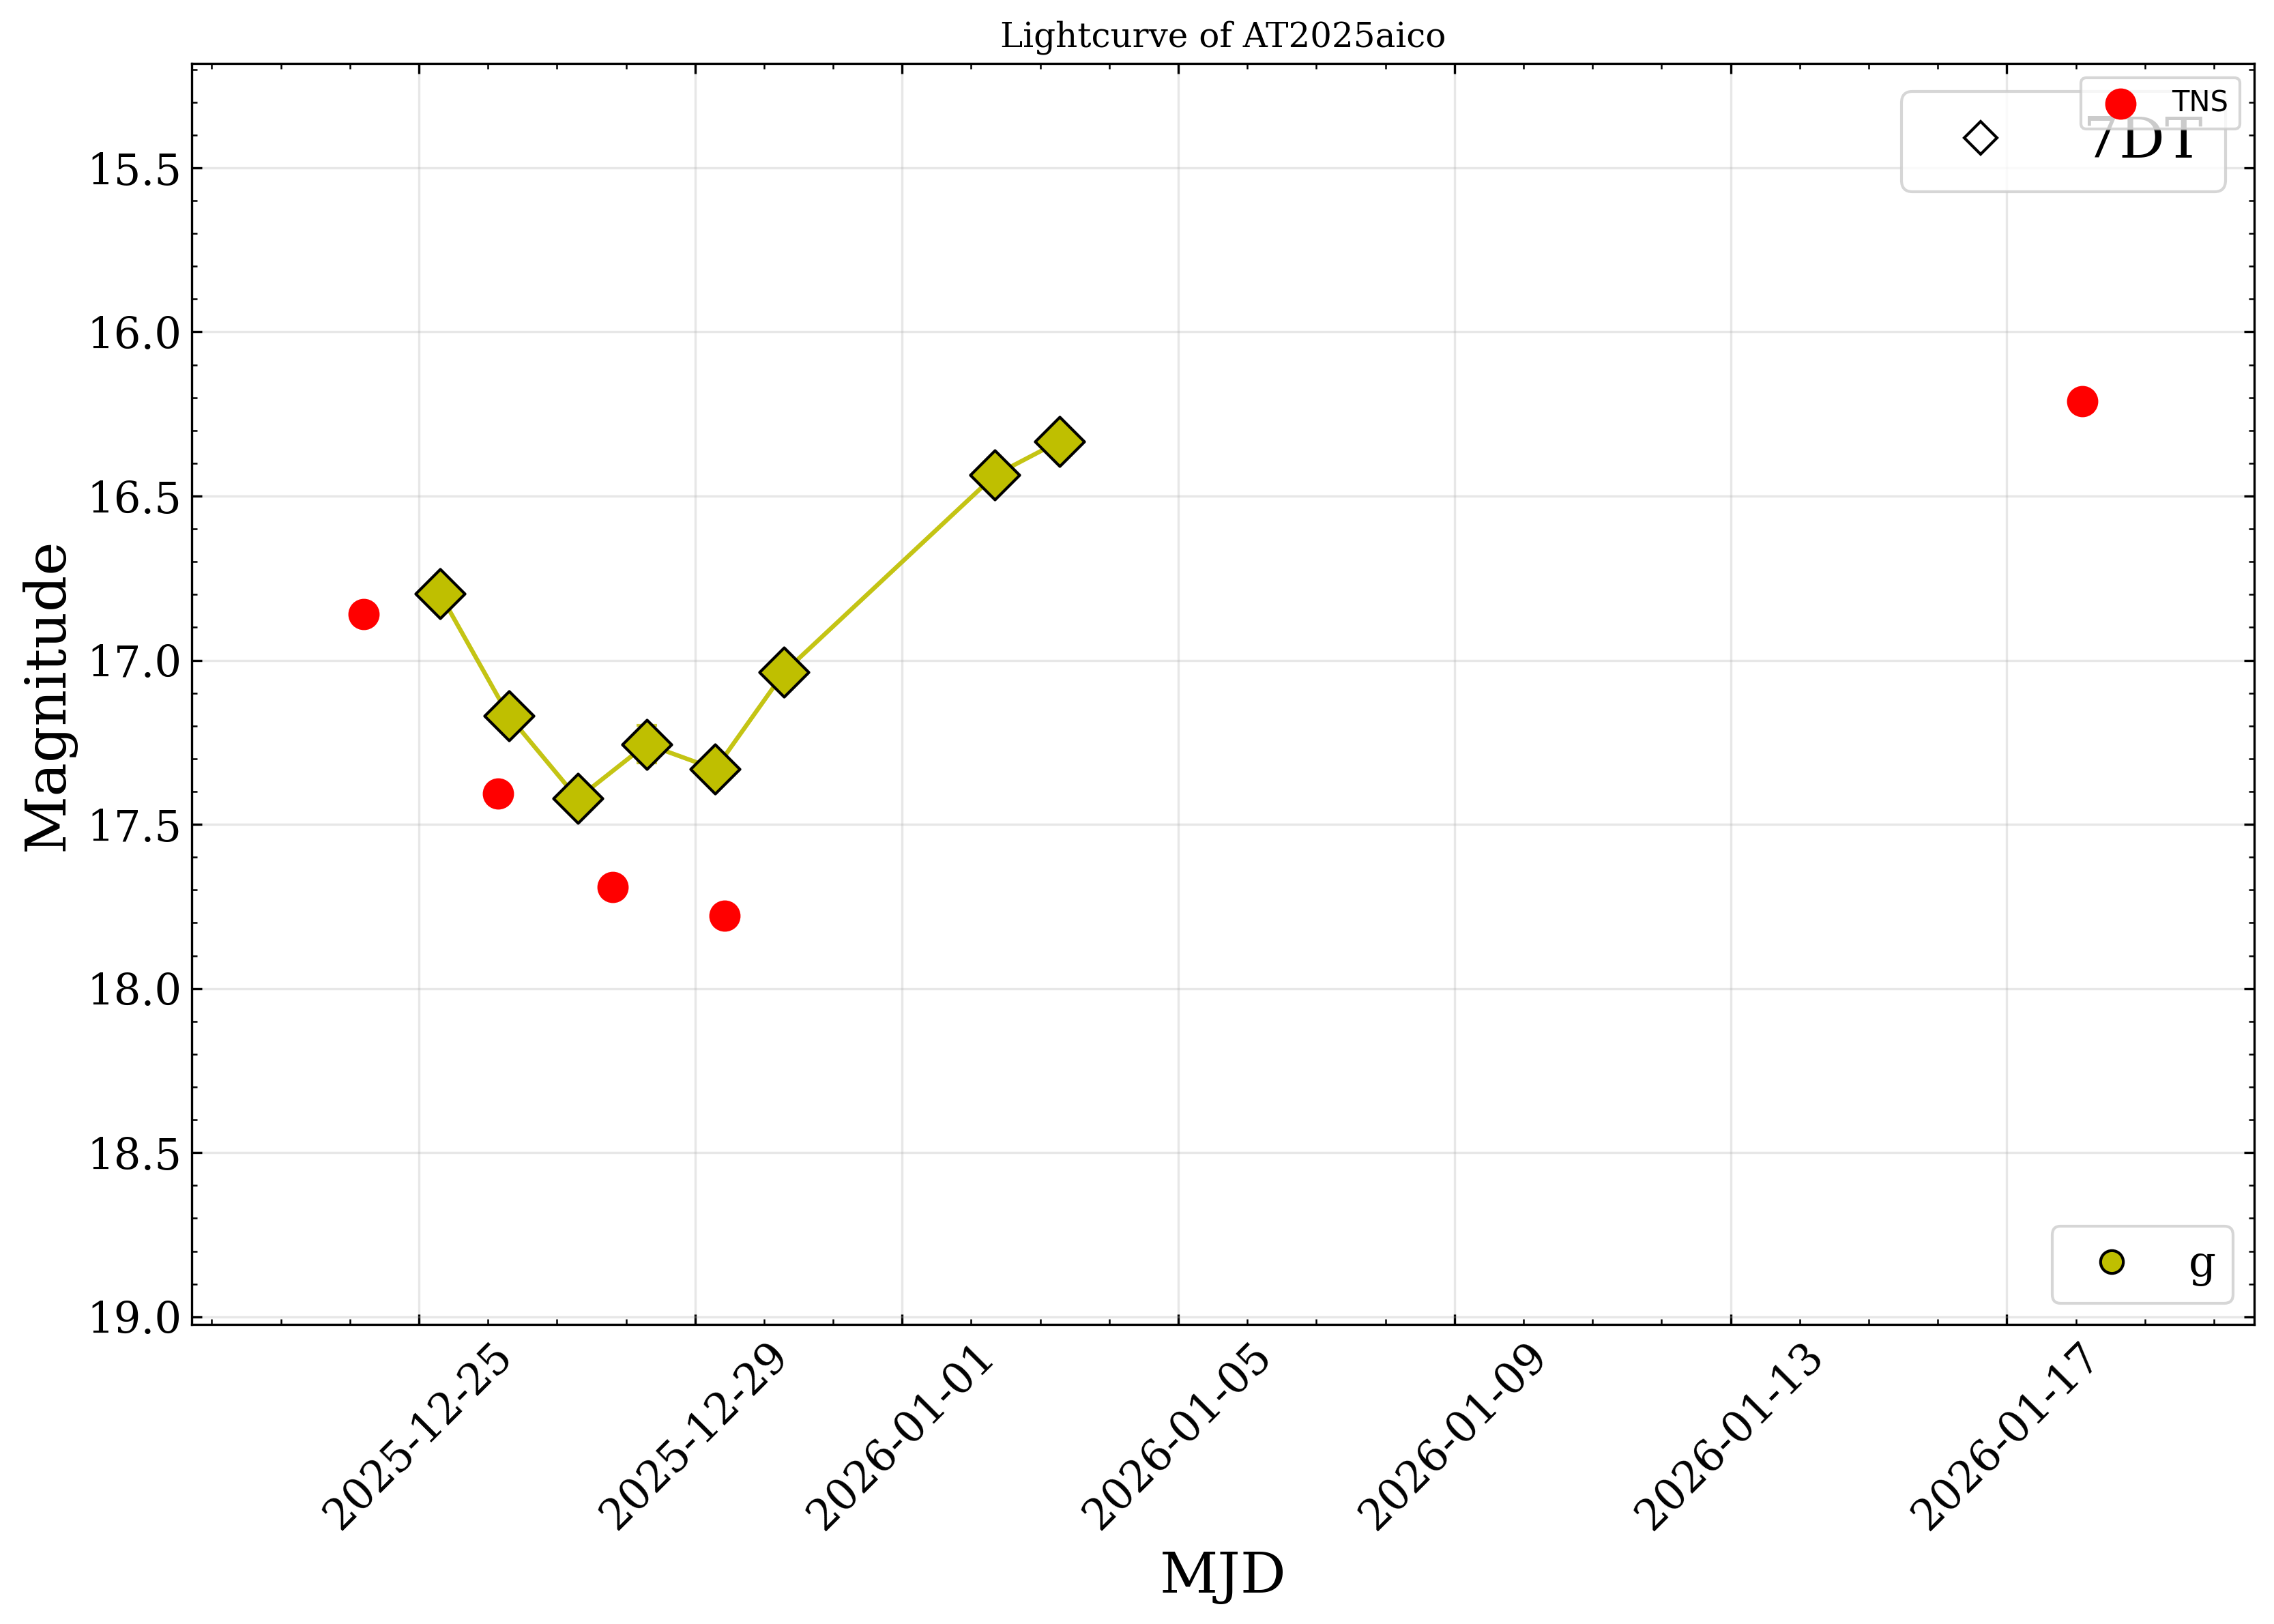

In [ ]:
fig, _, ax, tbl = lc.plot(target_ra, target_dec, flux_key = 'MAGSKY_APER')
fig = fig['g|7DT']
ax = ax['g|7DT']
ax.scatter(Time(tns_photometry['mjd'], format = 'mjd').datetime, tns_photometry['mag'], c = 'r', s = 100, label = 'TNS')
ax.legend()
ax.set_xlabel('MJD')
ax.set_ylabel('Magnitude')
ax.set_title('Lightcurve of AT2025aico')
ax.grid(True)

### 2. Compare with forced photometry

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import traceback
from ezphot.methods import PhotometricCalibration

def process_forced_photometry(args):
    idx, target_img = args
    try:
        target_catalog_forced = target_img.photometry_forced_circular(
            x_arr=target_ra,
            y_arr=target_dec,
            target_bkg=target_img.bkgmap,
            target_bkgrms=target_img.bkgrms,
            aperture_diameter_arcsec=[5, 7, 10],
            aperture_diameter_seeing=[3.5, 4.5],
            annulus_width_arcsec=5,
            visualize=False,
            verbose=False
        )

        photcal = PhotometricCalibration()
        target_catalog_forced = photcal.apply_zp(target_img, target_catalog_forced)

        return idx, target_catalog_forced

    except Exception as e:
        print(f"[ERROR] Image {idx} failed: {e}")
        traceback.print_exc()
        return idx, None


n_workers = min(len(target_imglist_g), 8)

with ThreadPoolExecutor(max_workers=n_workers) as executor:
    futures = [executor.submit(process_forced_photometry, (i, img))
               for i, img in enumerate(target_imglist_g)]

    results_forced = [None] * len(target_imglist_g)
    for future in as_completed(futures):
        idx, catalog = future.result()
        results_forced[idx] = catalog
        print(f"[{sum(r is not None for r in results_forced)}/{len(target_imglist_g)}] done")

target_forced_cataloglist_g = [cat for cat in results_forced if cat is not None]

Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT16/g/coadd_scaled_subbkg_7DT16_20260103_064023_AT2025aico_g_1x1_100.0s_0002.com.fits.circ.cat
[1/8] done
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT16/g/coadd_scaled_subbkg_7DT16_20260102_081815_AT2025aico_g_1x1_100.0s_0002.com.fits.circ.cat
[2/8] done
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT16/g/coadd_scaled_subbkg_7DT16_20251228_071050_AT2025aico_g_1x1_100.0s_0001.com.fits.circ.cat
[3/8] done
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT16/g/coadd_scaled_subbkg_7DT16_20251226_071338_AT2025aico_g_1x1_100.0s_0002.com.fits.circ.cat
[4/8] done
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT16/g/coadd_scaled_subbkg_7DT16_20251230_070213_AT2025aico_g_1x1_100.0s_0002.com.fits.circ.cat
[5/8] done
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2

Merging catalogs: 100%|██████████| 7/7 [00:00<00:00, 168.79it/s]


Matched 1 sources out of 1 input positions.
[WARNING] MAGERR_AUTO not found/or all masked in table. Ignoring flux error component.
[WARNING] ZPERR_AUTO not found/or all masked in table. Ignoring zp error component.
[WARNING] UL5SKY_AUTO not found/or all masked in table. Ignoring depth plot.


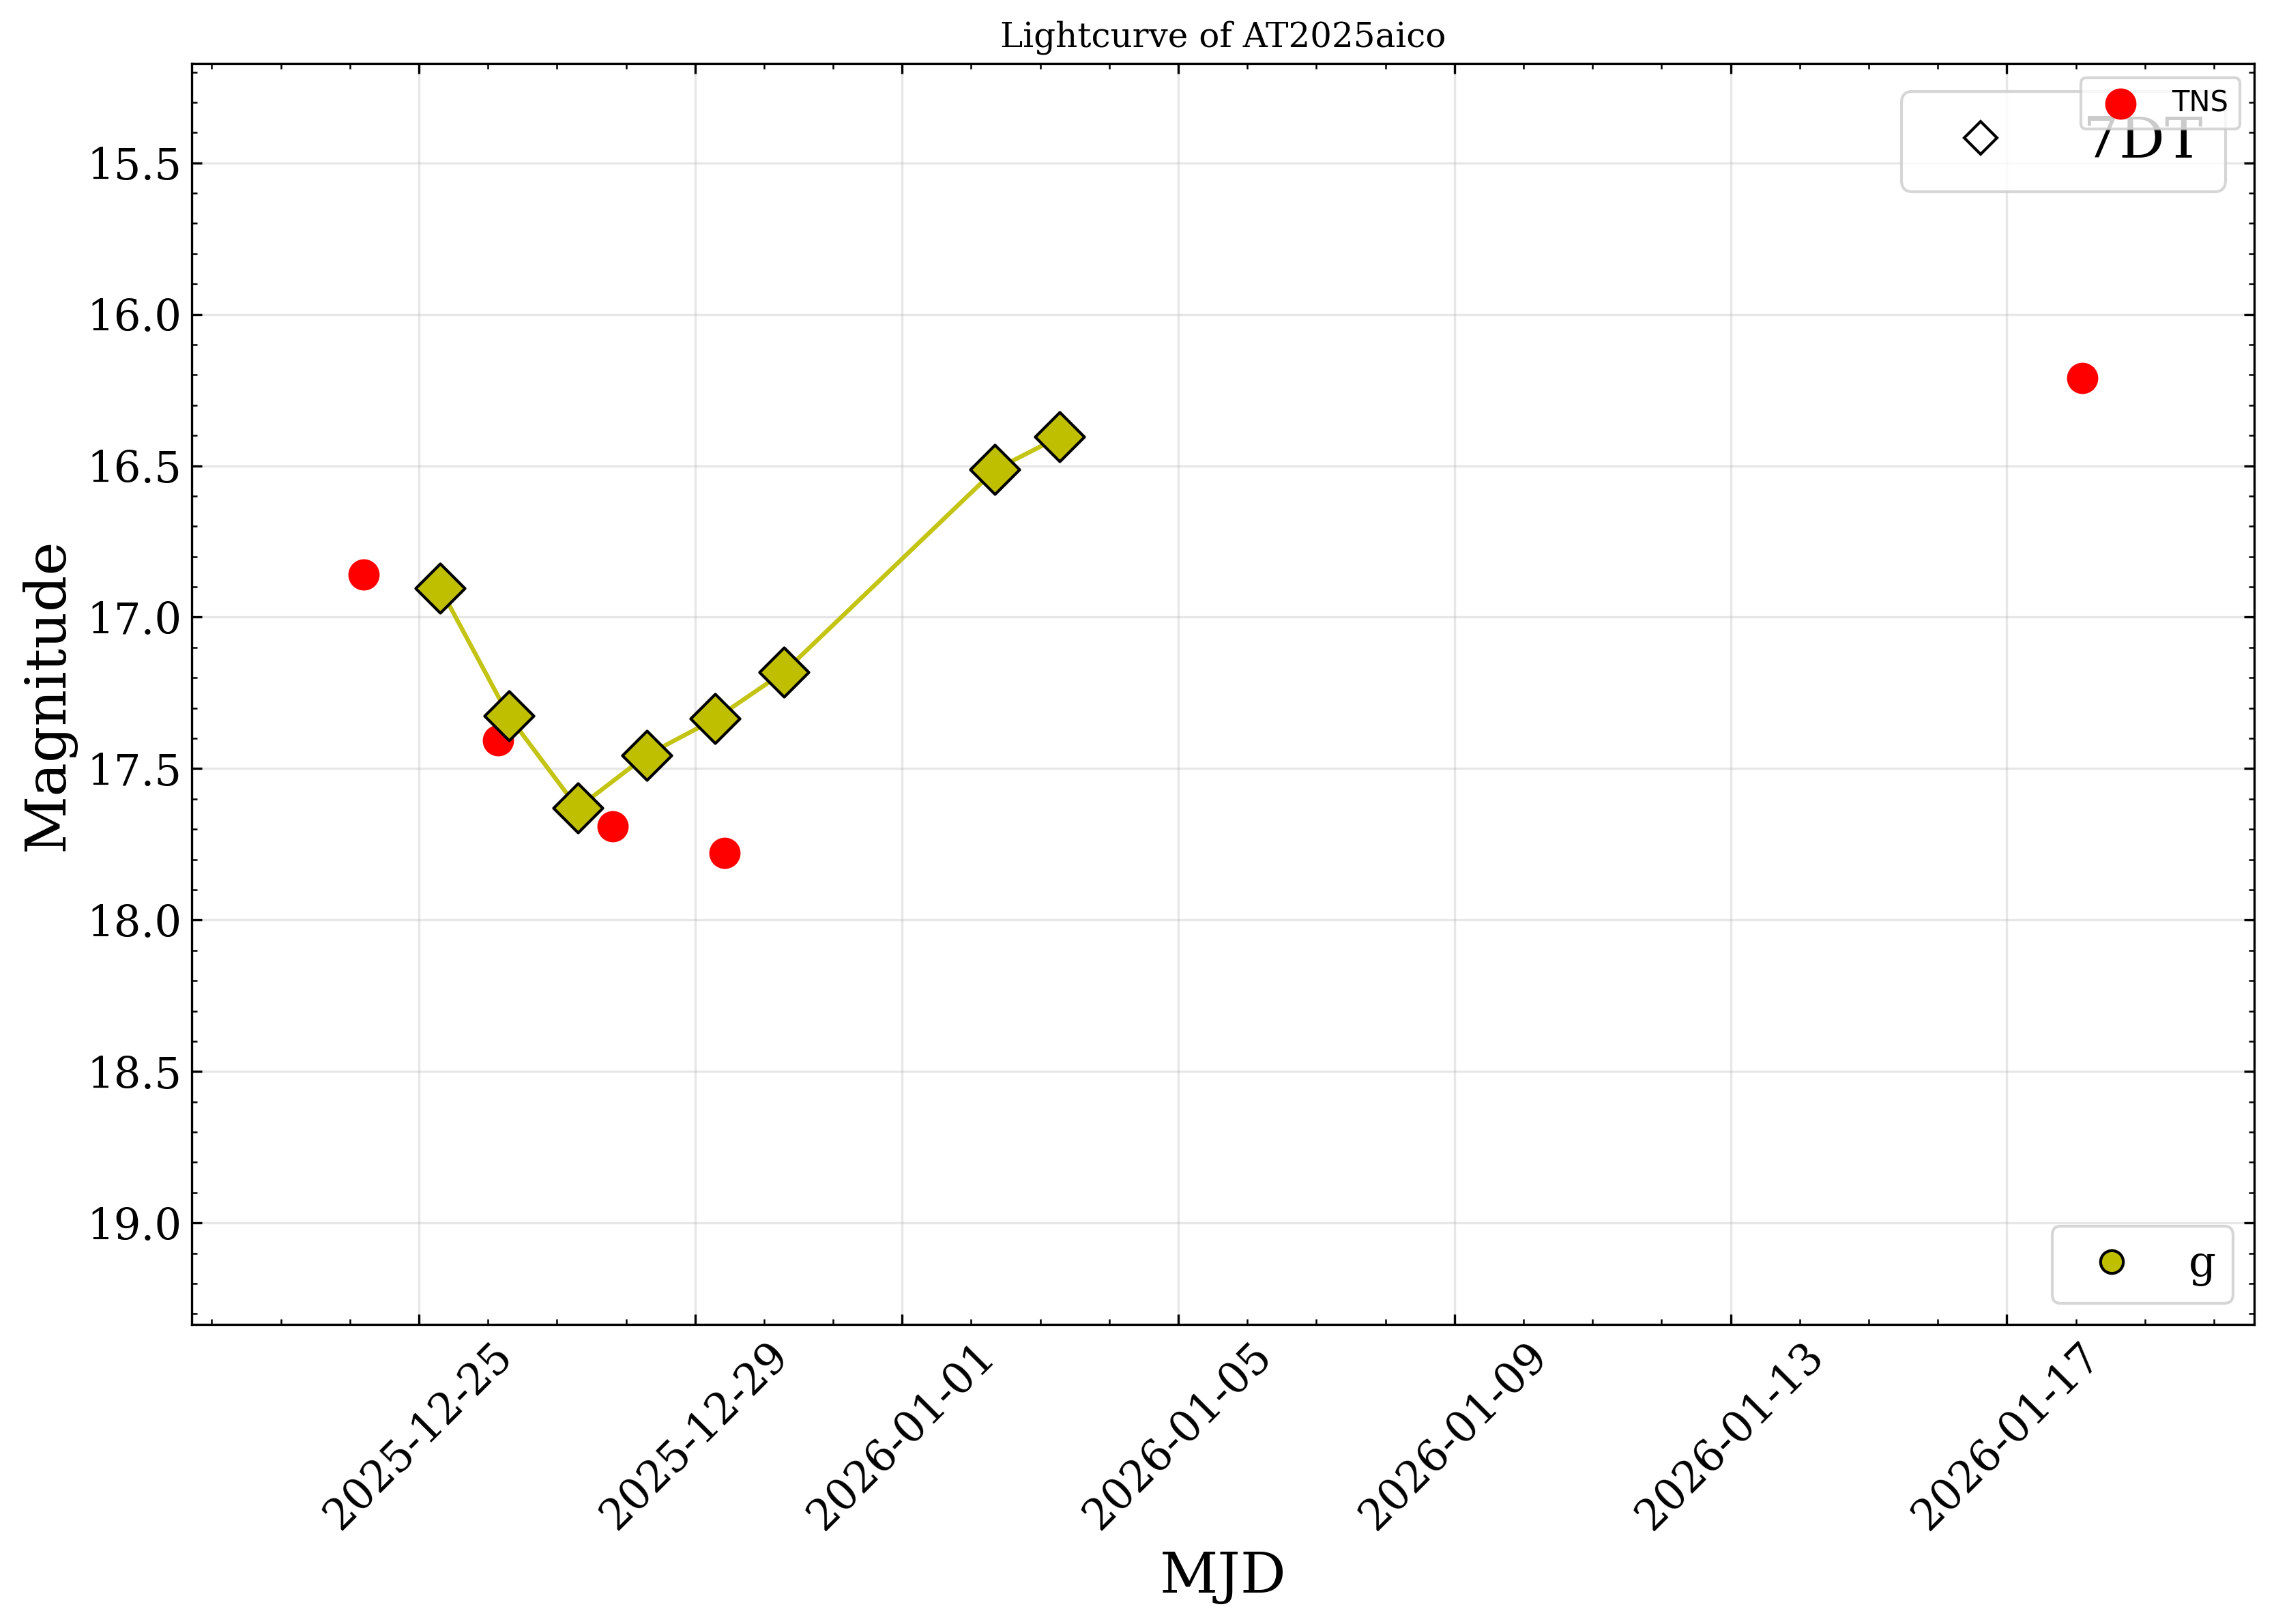

In [ ]:
lc = LightCurve(CatalogSet(target_forced_cataloglist_g))
fig, _, ax, tbl = lc.plot(target_ra, target_dec, flux_key = 'MAGSKY_APER')
fig = fig['g|7DT']
ax = ax['g|7DT']
ax.scatter(Time(tns_photometry['mjd'], format = 'mjd').datetime, tns_photometry['mag'], c = 'r', s = 100, label = 'TNS')
ax.legend()
ax.set_xlabel('MJD')
ax.set_ylabel('Magnitude')
ax.set_title('Lightcurve of AT2025aico')
ax.grid(True)

## Compare Photometric spectrum with observed spectrum

In [5]:
target_imgset_all.select_images(obs_start = '2025-12-24', obs_end = '2025-12-26')

In [6]:
target_imgset_all.target_df

,image_id,path,filter,exptime,obsdate,observatory,telname,objname,seeing,depth,ra,dec,fov_ra,fov_dec
0,1,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m850,300.0,2025-12-25T07:22:25.000,7DT,7DT08,AT2025aico,1.901496,17.004409,11:29:16.32,20:35:08.52,1.431,0.954
1,14,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m425,300.0,2025-12-25T07:27:47.000,7DT,7DT08,AT2025aico,1.818750,19.465900,11:29:16.32,20:35:08.52,1.431,0.954
2,20,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m475,300.0,2025-12-25T07:27:49.667,7DT,7DT03,AT2025aico,1.873110,19.616261,11:29:16.32,20:35:08.52,1.431,0.954
3,28,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m450,300.0,2025-12-25T07:22:27.000,7DT,7DT03,AT2025aico,1.981303,19.504791,11:29:16.32,20:35:08.52,1.431,0.954
4,36,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m500,300.0,2025-12-25T07:22:35.000,7DT,7DT09,AT2025aico,1.912755,19.659991,11:29:16.32,20:35:08.52,1.431,0.954
5,47,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m725,300.0,2025-12-25T07:28:00.667,7DT,7DT09,AT2025aico,1.566340,18.258530,11:29:16.32,20:35:08.52,1.431,0.954
6,48,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m575,300.0,2025-12-25T07:22:34.333,7DT,7DT06,AT2025aico,2.501078,19.297547,11:29:16.32,20:35:08.52,1.431,0.954
7,60,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m750,600.0,2025-12-25T07:25:15.167,7DT,7DT06,AT2025aico,2.095619,18.543656,11:29:16.32,20:35:08.52,1.431,0.954
8,65,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m875,300.0,2025-12-25T07:22:32.333,7DT,7DT13,AT2025aico,2.281921,16.380296,11:29:16.32,20:35:08.52,1.431,0.954
9,77,/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C...,m400,300.0,2025-12-25T07:27:57.000,7DT,7DT13,AT2025aico,2.353039,18.948971,11:29:16.32,20:35:08.52,1.431,0.954


In [7]:
target_imglist_first = target_imgset_all.target_images

In [ ]:
from multiprocessing import Pool
import traceback

# Global in each worker process — populated by the initializer
_worker_imglist = None

def worker_init(imglist):
    global _worker_imglist
    _worker_imglist = imglist

def process_single_image(idx):
    target_img = _worker_imglist[idx]
    try:
        target_catalog = target_img.photometry_sex(
            target_bkg=target_img.bkgmap,
            target_bkgrms=target_img.bkgrms,
            visualize=False,
            verbose=True,
            aperture_diameter_arcsec=[2, 4, 6, 8],
            aperture_diameter_seeing=[1.5, 2.5, 3.5, 4.5],
            annulus_width_arcsec=None
        )

        target_img, target_catalog, _, _ = target_img.photometric_calibration(
            target_catalog,
            mag_lower=11,
            mag_upper=17.5,
            visualize=False,
            verbose=True
        )

        target_catalog.select_sources(target_ra, target_dec)
        return idx, target_catalog

    except Exception as e:
        print(f"[ERROR] Image {idx} failed: {e}")
        traceback.print_exc()
        return idx, None


if __name__ == '__main__':
    n_workers = min(len(target_imglist_first), 32)

    with Pool(
        processes=n_workers,
        initializer=worker_init,
        initargs=(target_imglist_first,)   # passed once per worker, not per task
    ) as pool:
        raw = pool.map(process_single_image, range(len(target_imglist_first)))

    results = [None] * len(target_imglist_first)
    for idx, catalog in raw:
        results[idx] = catalog
        print(f"[{sum(r is not None for r in results)}/{len(target_imglist_first)}] done")

    target_cataloglist_first = [cat for cat in results if cat is not None]    

Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT09/m500/subbkg_coadd_scaled_subbkg_7DT09_20251225_072420_AT2025aico_m500_1x1_100.0s_0002.com.fits
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT16/g/subbkg_coadd_scaled_subbkg_7DT16_20251225_072414_AT2025aico_g_1x1_100.0s_0002.com.fits
Start SExtractor process...=====================
RUN COMMAND: source-extractor /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT09/m500/subbkg_coadd_scaled_subbkg_7DT09_20251225_072420_AT2025aico_m500_1x1_100.0s_0002.com.fits -c /home/hhchoi1022/ezphot/config/specific/7DT_C361K_HIGH_1x1/7DT_C361K_HIGH_1x1.sexconfig -BACK_TYPE MANUAL -BACK_VALUE 0 -SEEING_FWHM 2.20 -PIXEL_SCALE 0.5050000000000799 -PHOT_APERTURES 3.96,7.92,11.88,15.84,6.53,10.88,15.24,19.59 -SATUR_LEVEL 60000.24315369129 -PHOT_AUTOPARAMS 2.5,3.5 -DETECT_THRESH 5 -BACKPHOTO_TYPE GLOBAL -CATALOG_NAME /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HI

Merging catalogs: 100%|██████████| 22/22 [00:00<00:00, 187.27it/s]


Matched 1 sources out of 1 input positions.


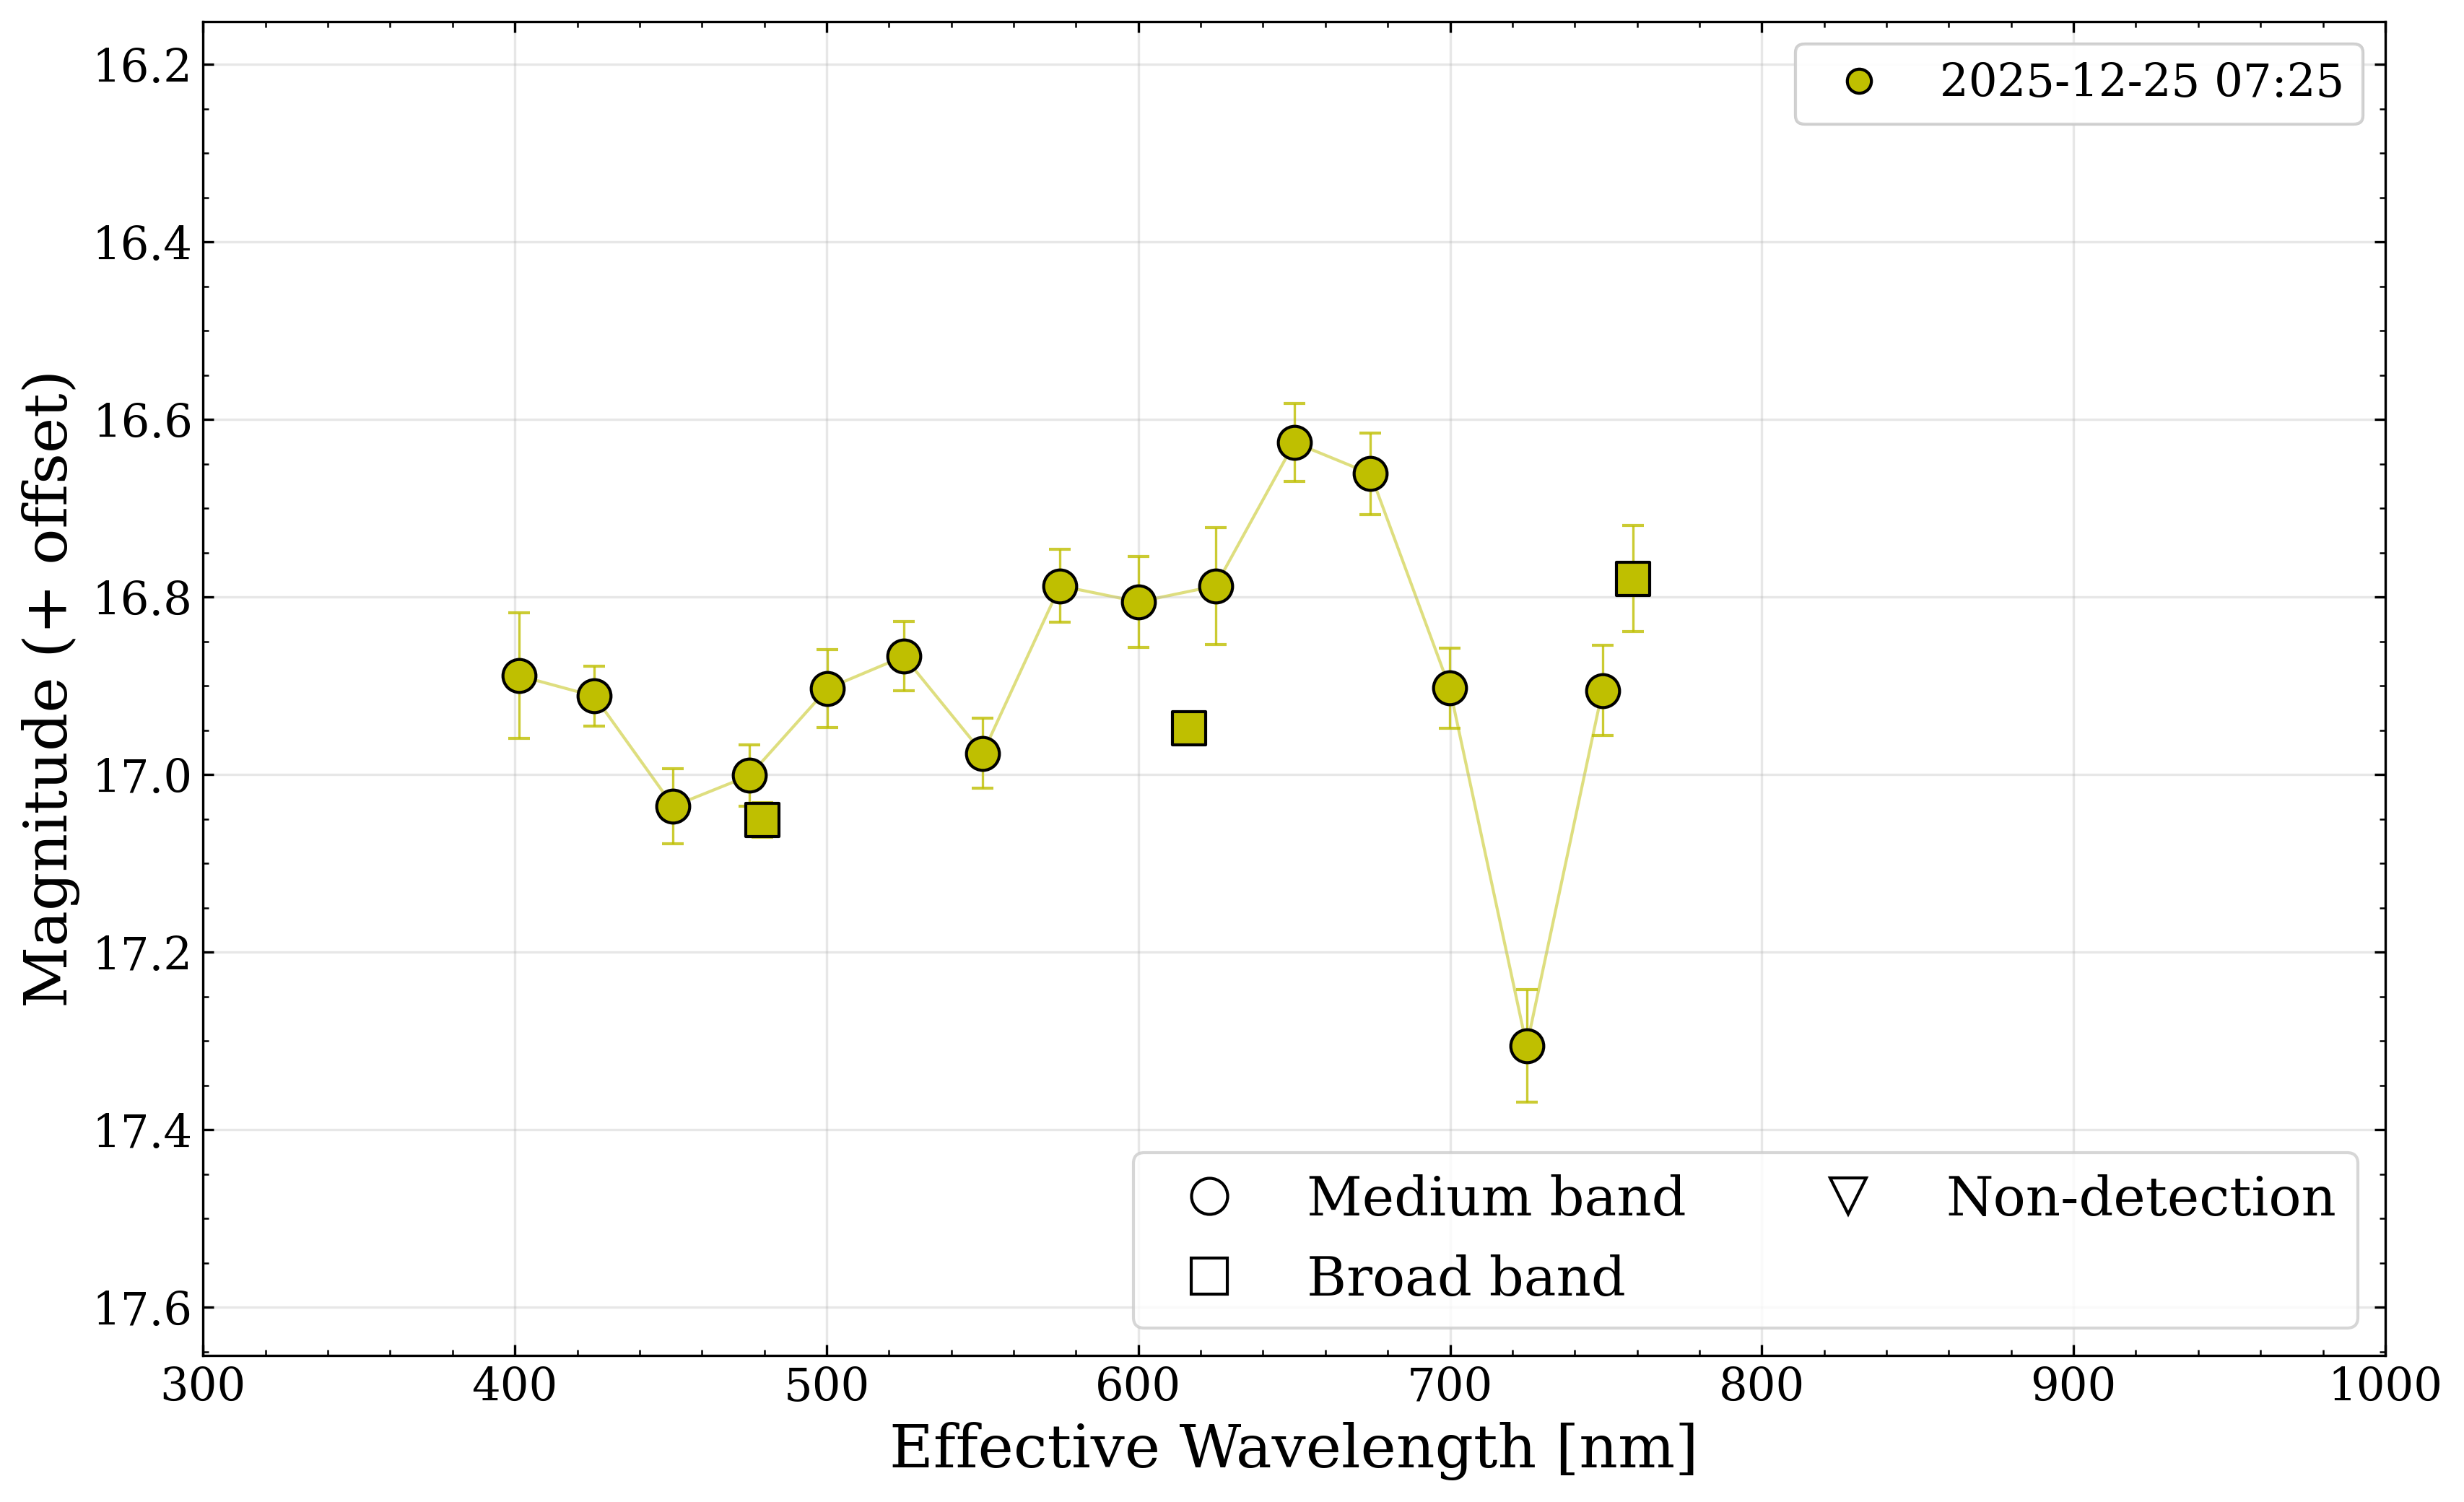

In [ ]:
from ezphot.dataobjects import PhotometricSpectrum
photspec = PhotometricSpectrum(CatalogSet(target_cataloglist_first))
fig_photspec, _, ax_photspec, tbl_photspec = photspec.plot(target_ra, target_dec,
flux_key = 'MAGSKY_APER_4')
fig_photspec = fig_photspec['2025-12-25 07:25']
ax_photspec = ax_photspec['2025-12-25 07:25']


In [ ]:
# Load spectrum from TNS
tns_spectra['obsdate'] = Time(tns_spectra['jd'], format = 'jd').isot
tns_spectra['mjd'] = Time(tns_spectra['jd'], format = 'jd').mjd
target_spec_row = tns_spectra[0]
spec_data = ascii.read(target_spec_row['ascii_file'])
from ezphot.dataobjects import Spectrum
spec = Spectrum(target_spec_row['ascii_file'])
spec_synphot = spec.synphot()

ASCII file read: /home/hhchoi1022/bridge/alert/tns/2025aico/TNS/tns_2025aico_2025-12-25_08-03-14_SOAR_Goodman_None.txt
Flux unit estimated from data: FLAMB
Wavelength unit estimated from data: AA


In [ ]:

import numpy as np
ax_photspec.plot(spec.wavelength/10, np.array(spec.ab.flux), c = 'r', label = 'TNS', alpha = 0.2)
for filter, synphot_dict in spec_synphot[0].items():
    if filter in tbl_photspec['filter']:
        ax_photspec.scatter(synphot_dict['wl_pivot'].value, synphot_dict['mag'], c = 'r', label = 'TNS')

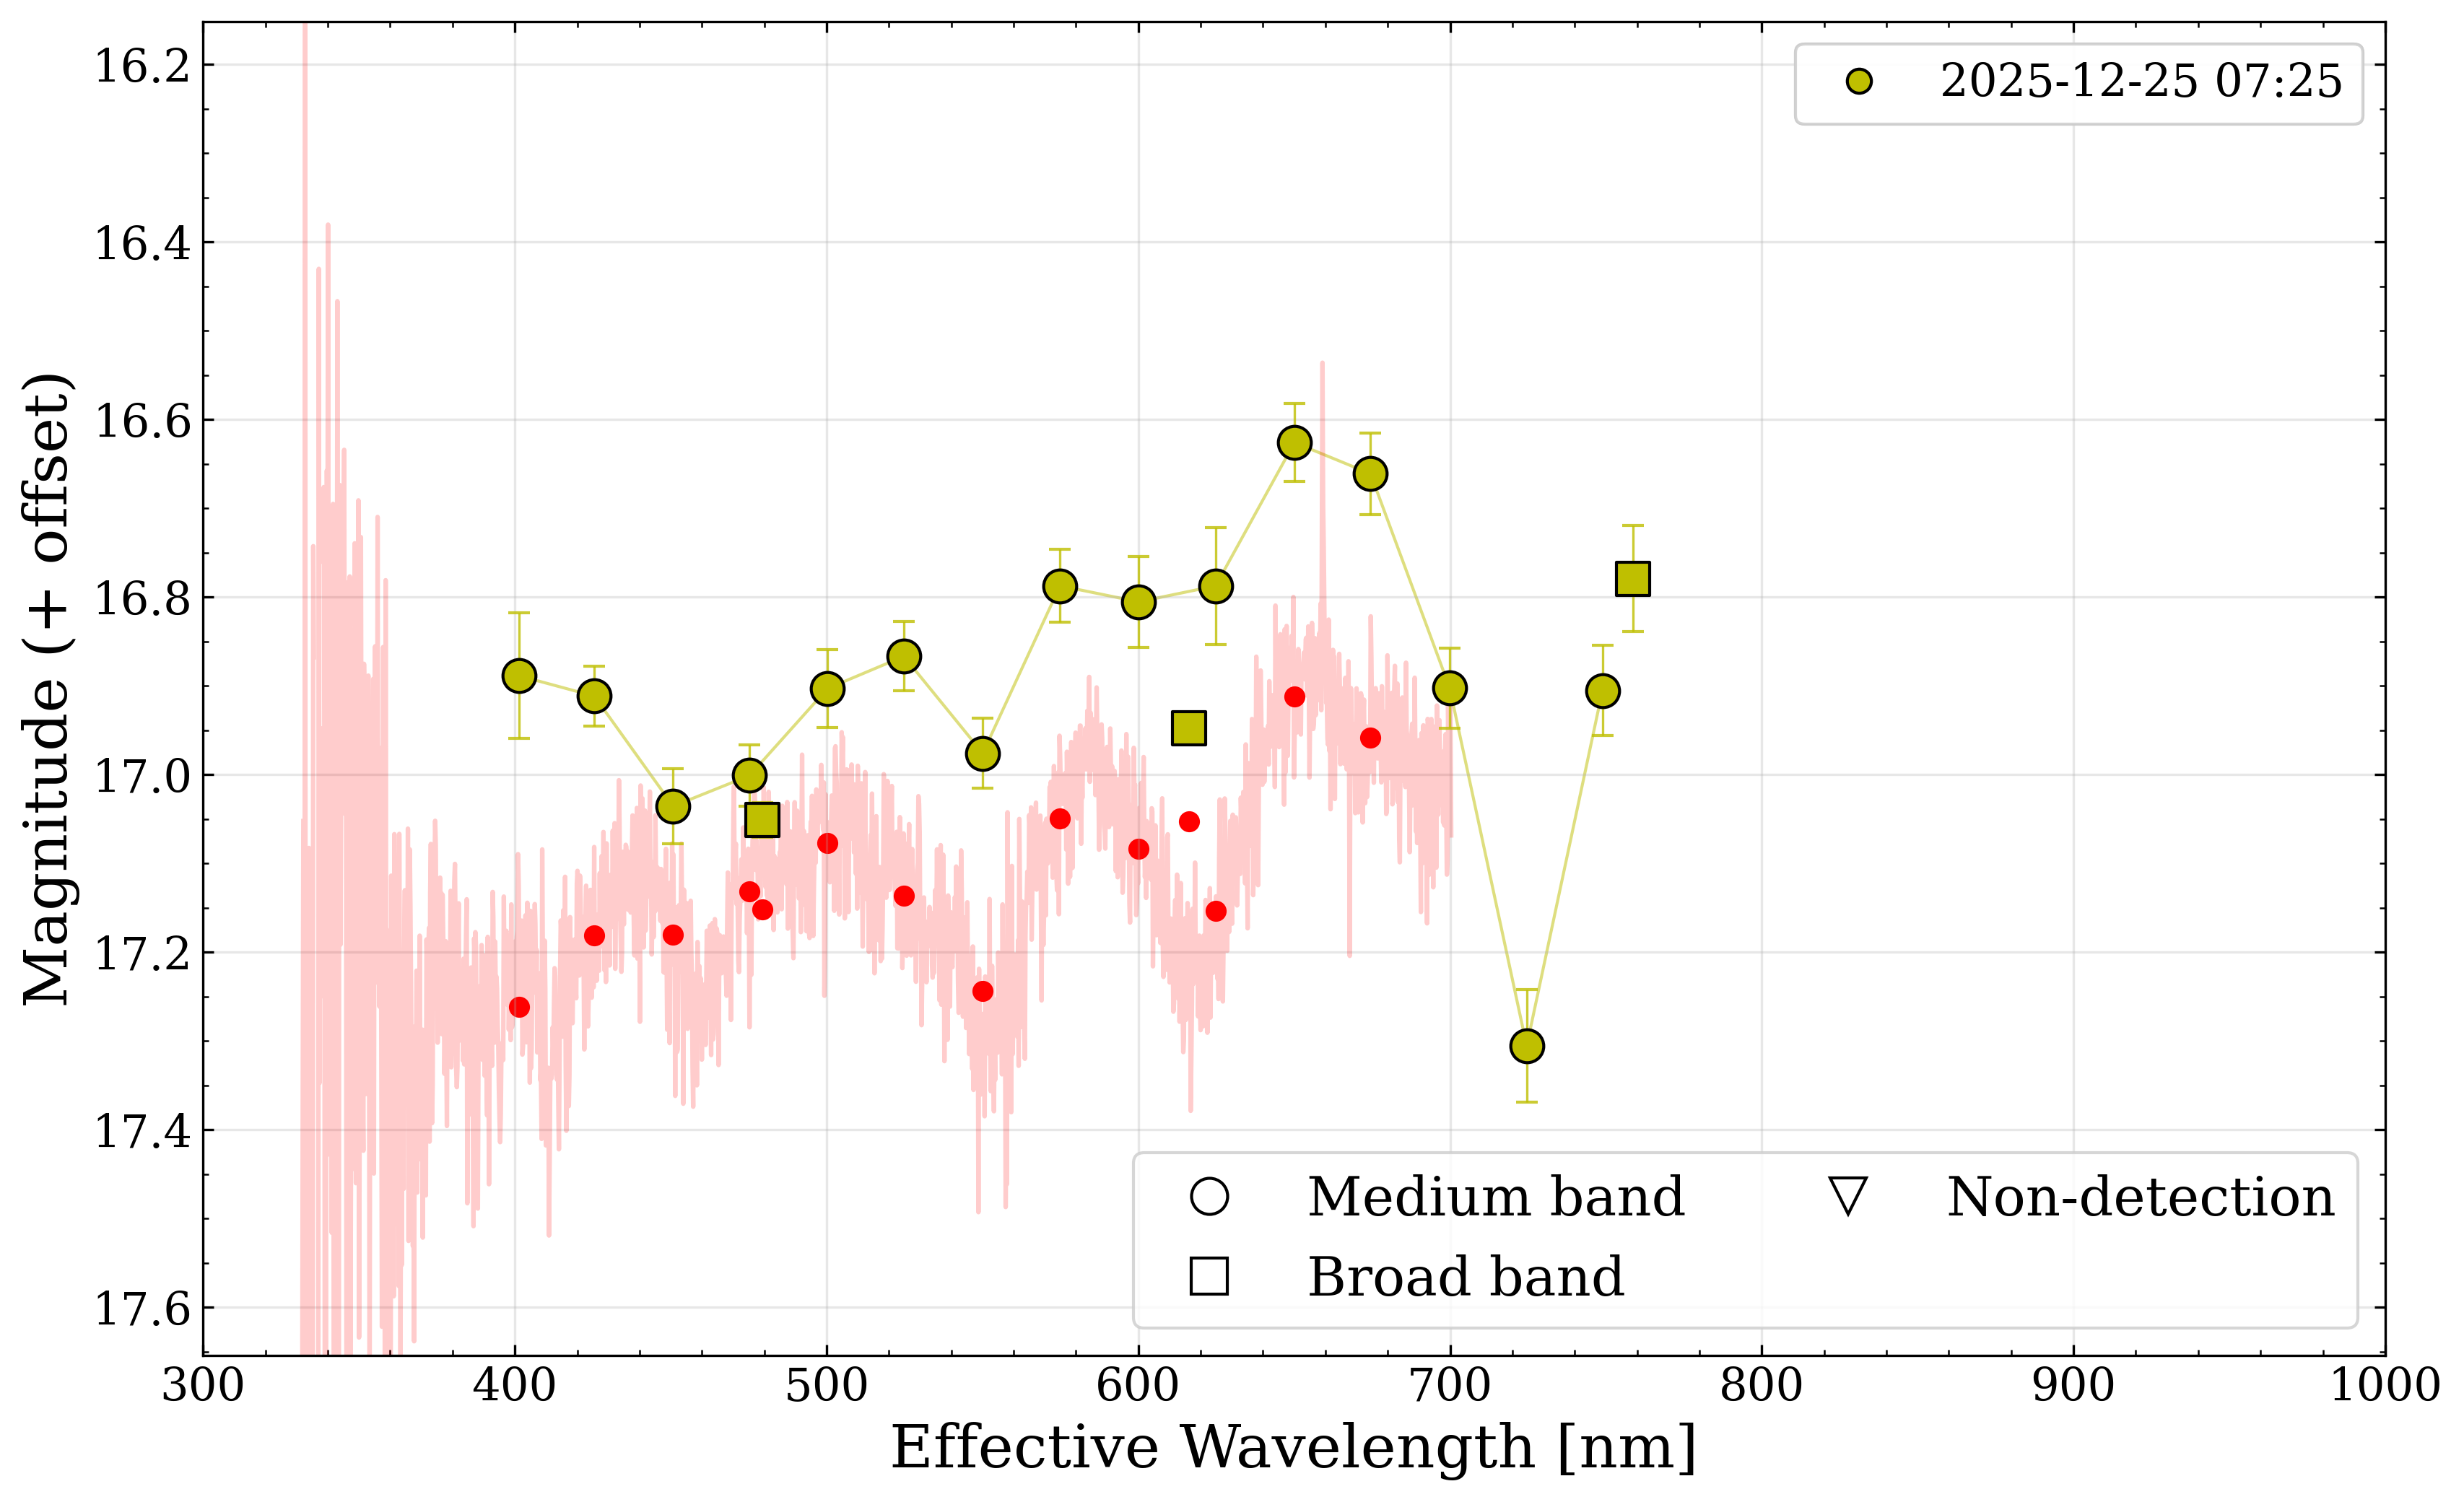

In [ ]:

fig_photspec

In [ ]:
from multiprocessing import Pool
from ezphot.methods import PhotometricCalibration
import traceback

_worker_imglist = None

def worker_init(imglist):
    global _worker_imglist
    _worker_imglist = imglist

def process_forced_photometry(idx):
    target_img = _worker_imglist[idx]
    try:
        target_catalog_forced = target_img.photometry_forced_circular(
            x_arr=target_ra,
            y_arr=target_dec,
            target_bkg=target_img.bkgmap,
            target_bkgrms=target_img.bkgrms,
            aperture_diameter_arcsec=[2, 4, 6, 8],
            aperture_diameter_seeing=[1.5, 2.5, 3.5, 4.5],
            annulus_width_arcsec=5,
            visualize=False,
            verbose=False
        )

        photcal = PhotometricCalibration()
        target_catalog_forced = photcal.apply_zp(target_img, target_catalog_forced)

        return idx, target_catalog_forced

    except Exception as e:
        print(f"[ERROR] Image {idx} failed: {e}")
        traceback.print_exc()
        return idx, None


if __name__ == '__main__':
    target_imglist_first = [cat.target_img for cat in target_cataloglist_first]
    n_workers = min(len(target_imglist_first), 32)

    with Pool(
        processes=n_workers,
        initializer=worker_init,
        initargs=(target_imglist_first,)
    ) as pool:
        raw = pool.map(process_forced_photometry, range(len(target_imglist_first)))

    results_forced = [None] * len(target_imglist_first)
    for idx, catalog in raw:
        results_forced[idx] = catalog
        print(f"[{sum(r is not None for r in results_forced)}/{len(target_imglist_first)}] done")

    target_forced_cataloglist_first = [cat for cat in results_forced if cat is not None]

Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT08/m850/coadd_scaled_subbkg_7DT08_20251225_072410_AT2025aico_m850_1x1_100.0s_0002.com.fits.circ.cat
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT16/g/coadd_scaled_subbkg_7DT16_20251225_072414_AT2025aico_g_1x1_100.0s_0002.com.fits.circ.cat
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT09/m500/coadd_scaled_subbkg_7DT09_20251225_072420_AT2025aico_m500_1x1_100.0s_0002.com.fits.circ.cat
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT06/m750/coadd_scaled_subbkg_7DT06_20251225_072952_AT2025aico_m750_1x1_100.0s_0002.com.fits.circ.cat
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT13/m400/coadd_scaled_subbkg_7DT13_20251225_072942_AT2025aico_m400_1x1_100.0s_0002.com.fits.circ.cat
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT04/m700/coadd_scaled

Merging catalogs: 100%|██████████| 22/22 [00:00<00:00, 196.13it/s]


Matched 1 sources out of 1 input positions.


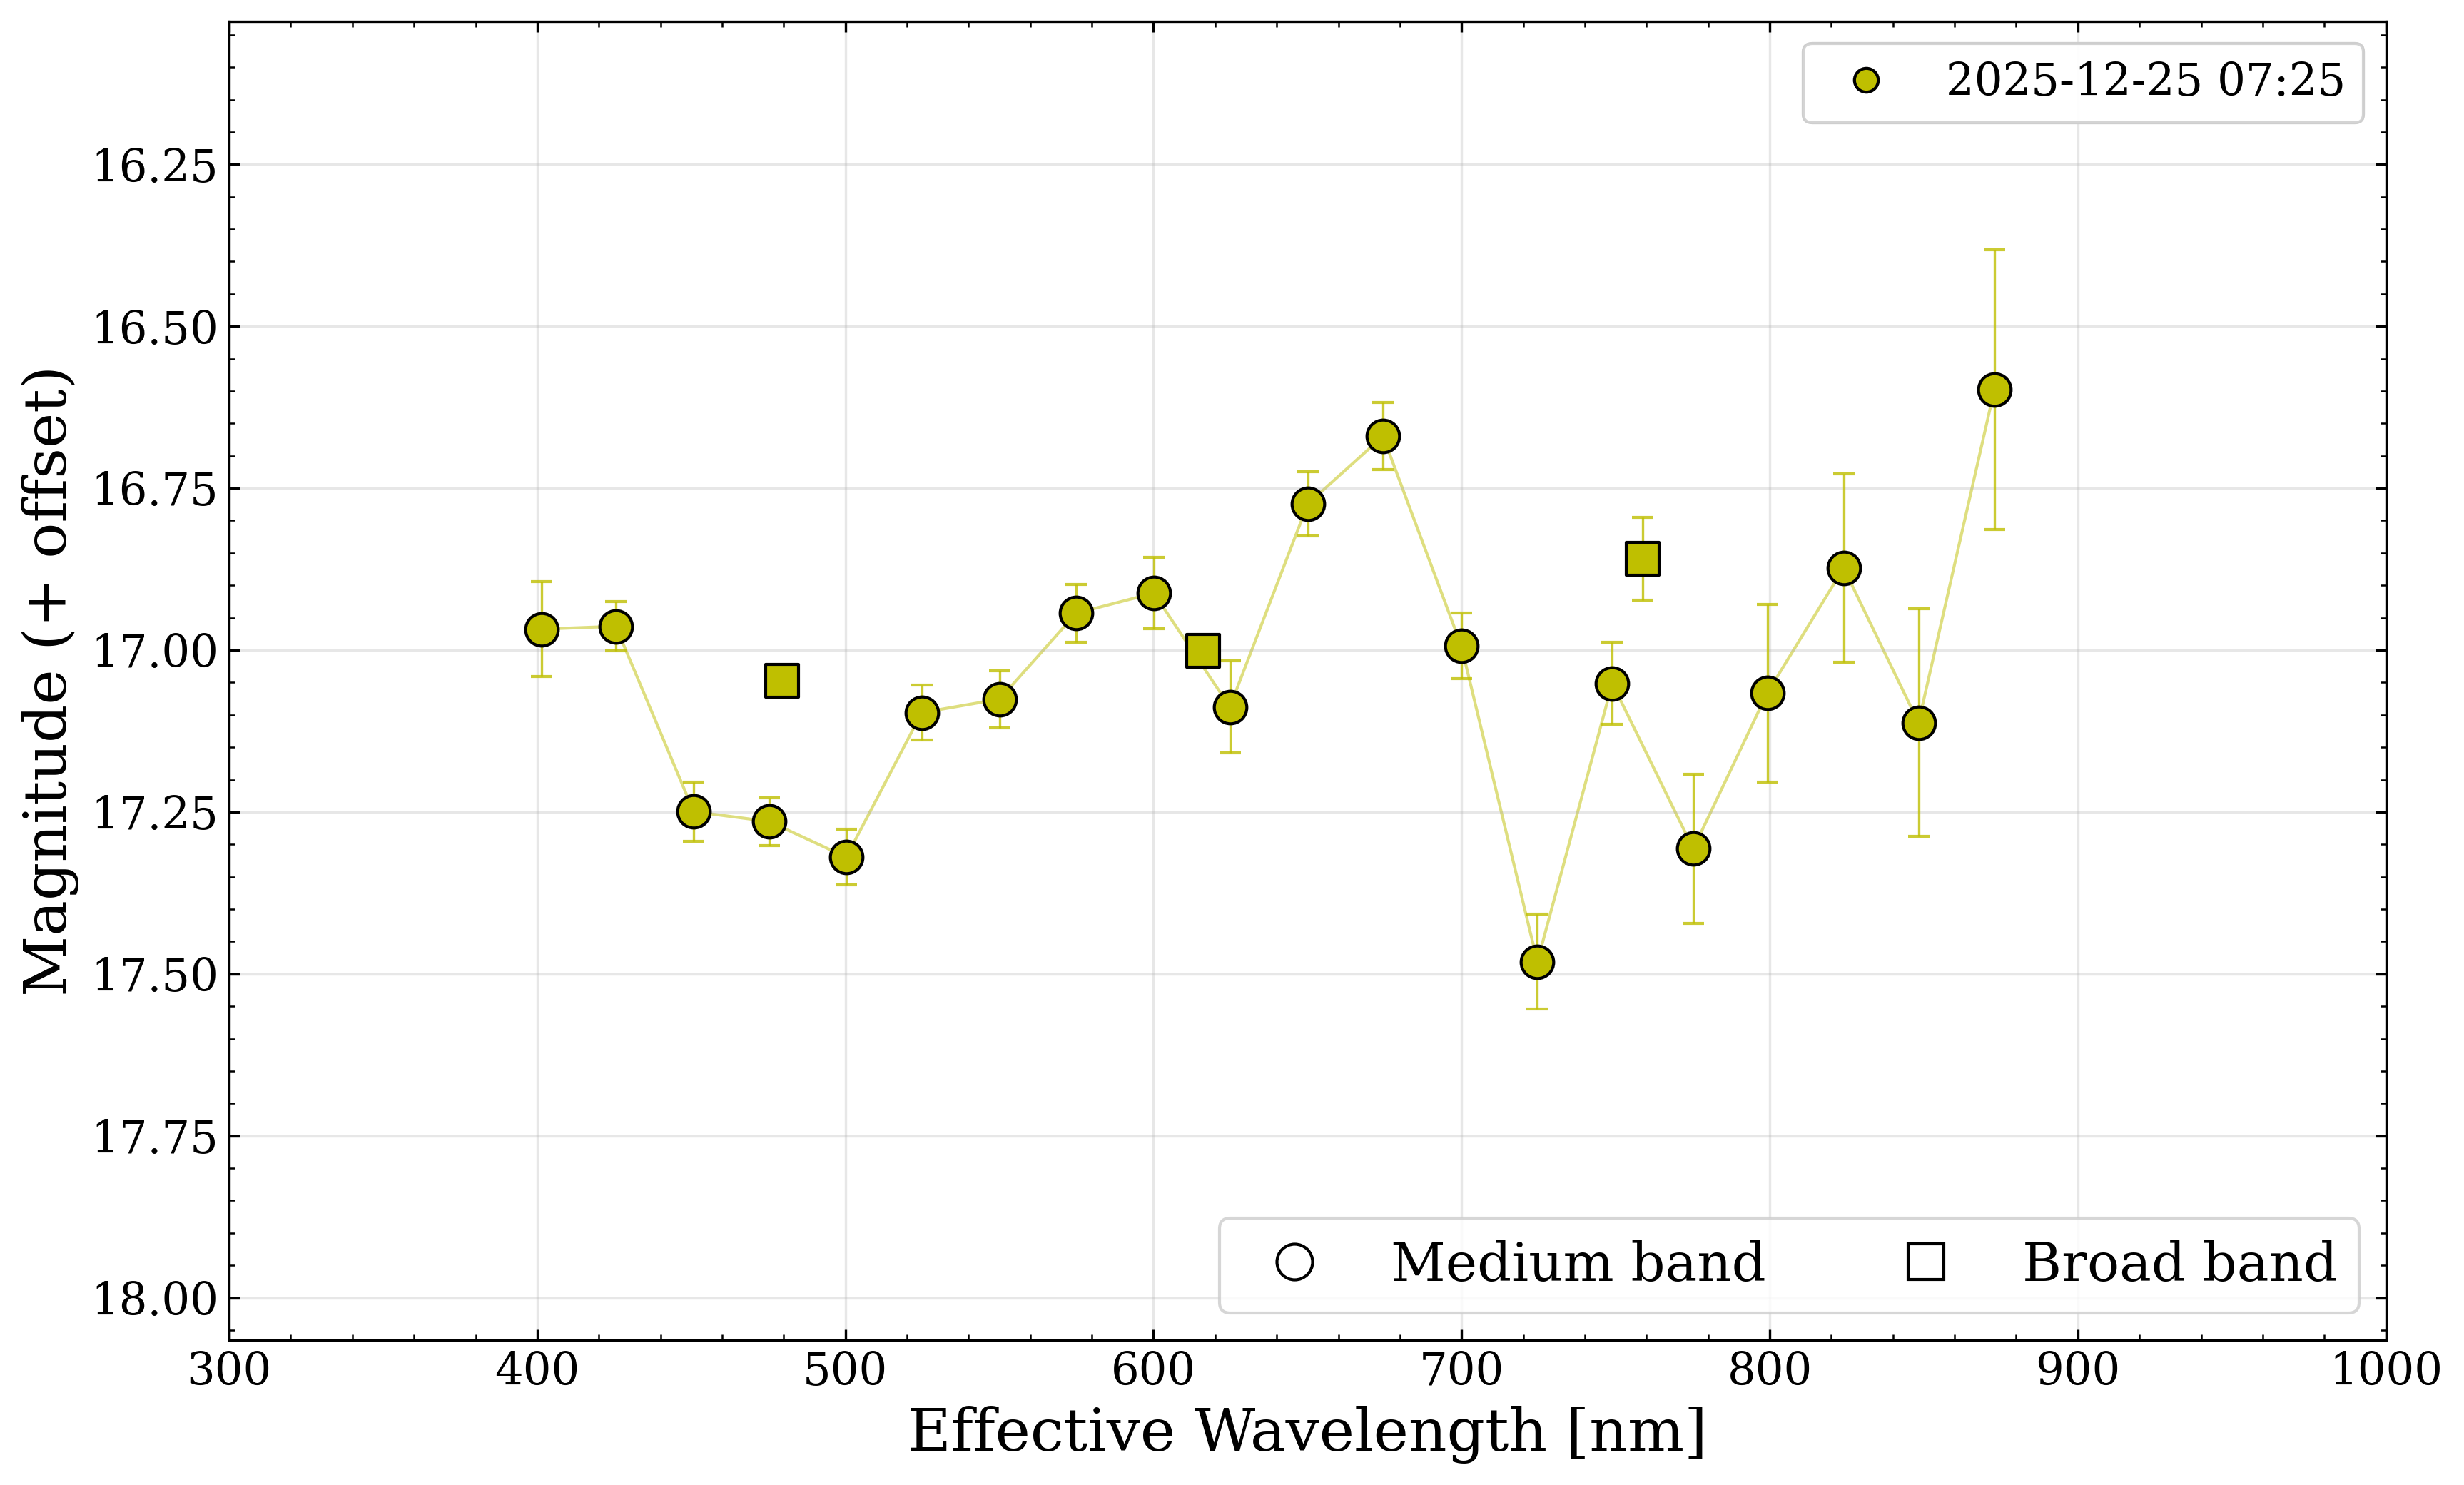

In [ ]:
from ezphot.dataobjects import PhotometricSpectrum
for catalog in target_forced_cataloglist_first:
    catalog.select_sources(target_ra, target_dec)
photspec = PhotometricSpectrum(CatalogSet(target_forced_cataloglist_first))
fig_photspec, _, ax_photspec, tbl_photspec = photspec.plot(target_ra, target_dec,
flux_key = 'MAGSKY_APER',
overplot_stamp = False)
fig_photspec = fig_photspec['2025-12-25 07:25']
ax_photspec = ax_photspec['2025-12-25 07:25']

In [ ]:
import numpy as np
ax_photspec.plot(spec.wavelength/10, np.array(spec.ab.flux), c = 'r', label = 'TNS', alpha = 0.2)
for filter, synphot_dict in spec_synphot[0].items():
    if filter in tbl_photspec['filter']:
        ax_photspec.scatter(synphot_dict['wl_pivot'].value, synphot_dict['mag'], c = 'r', label = 'TNS')

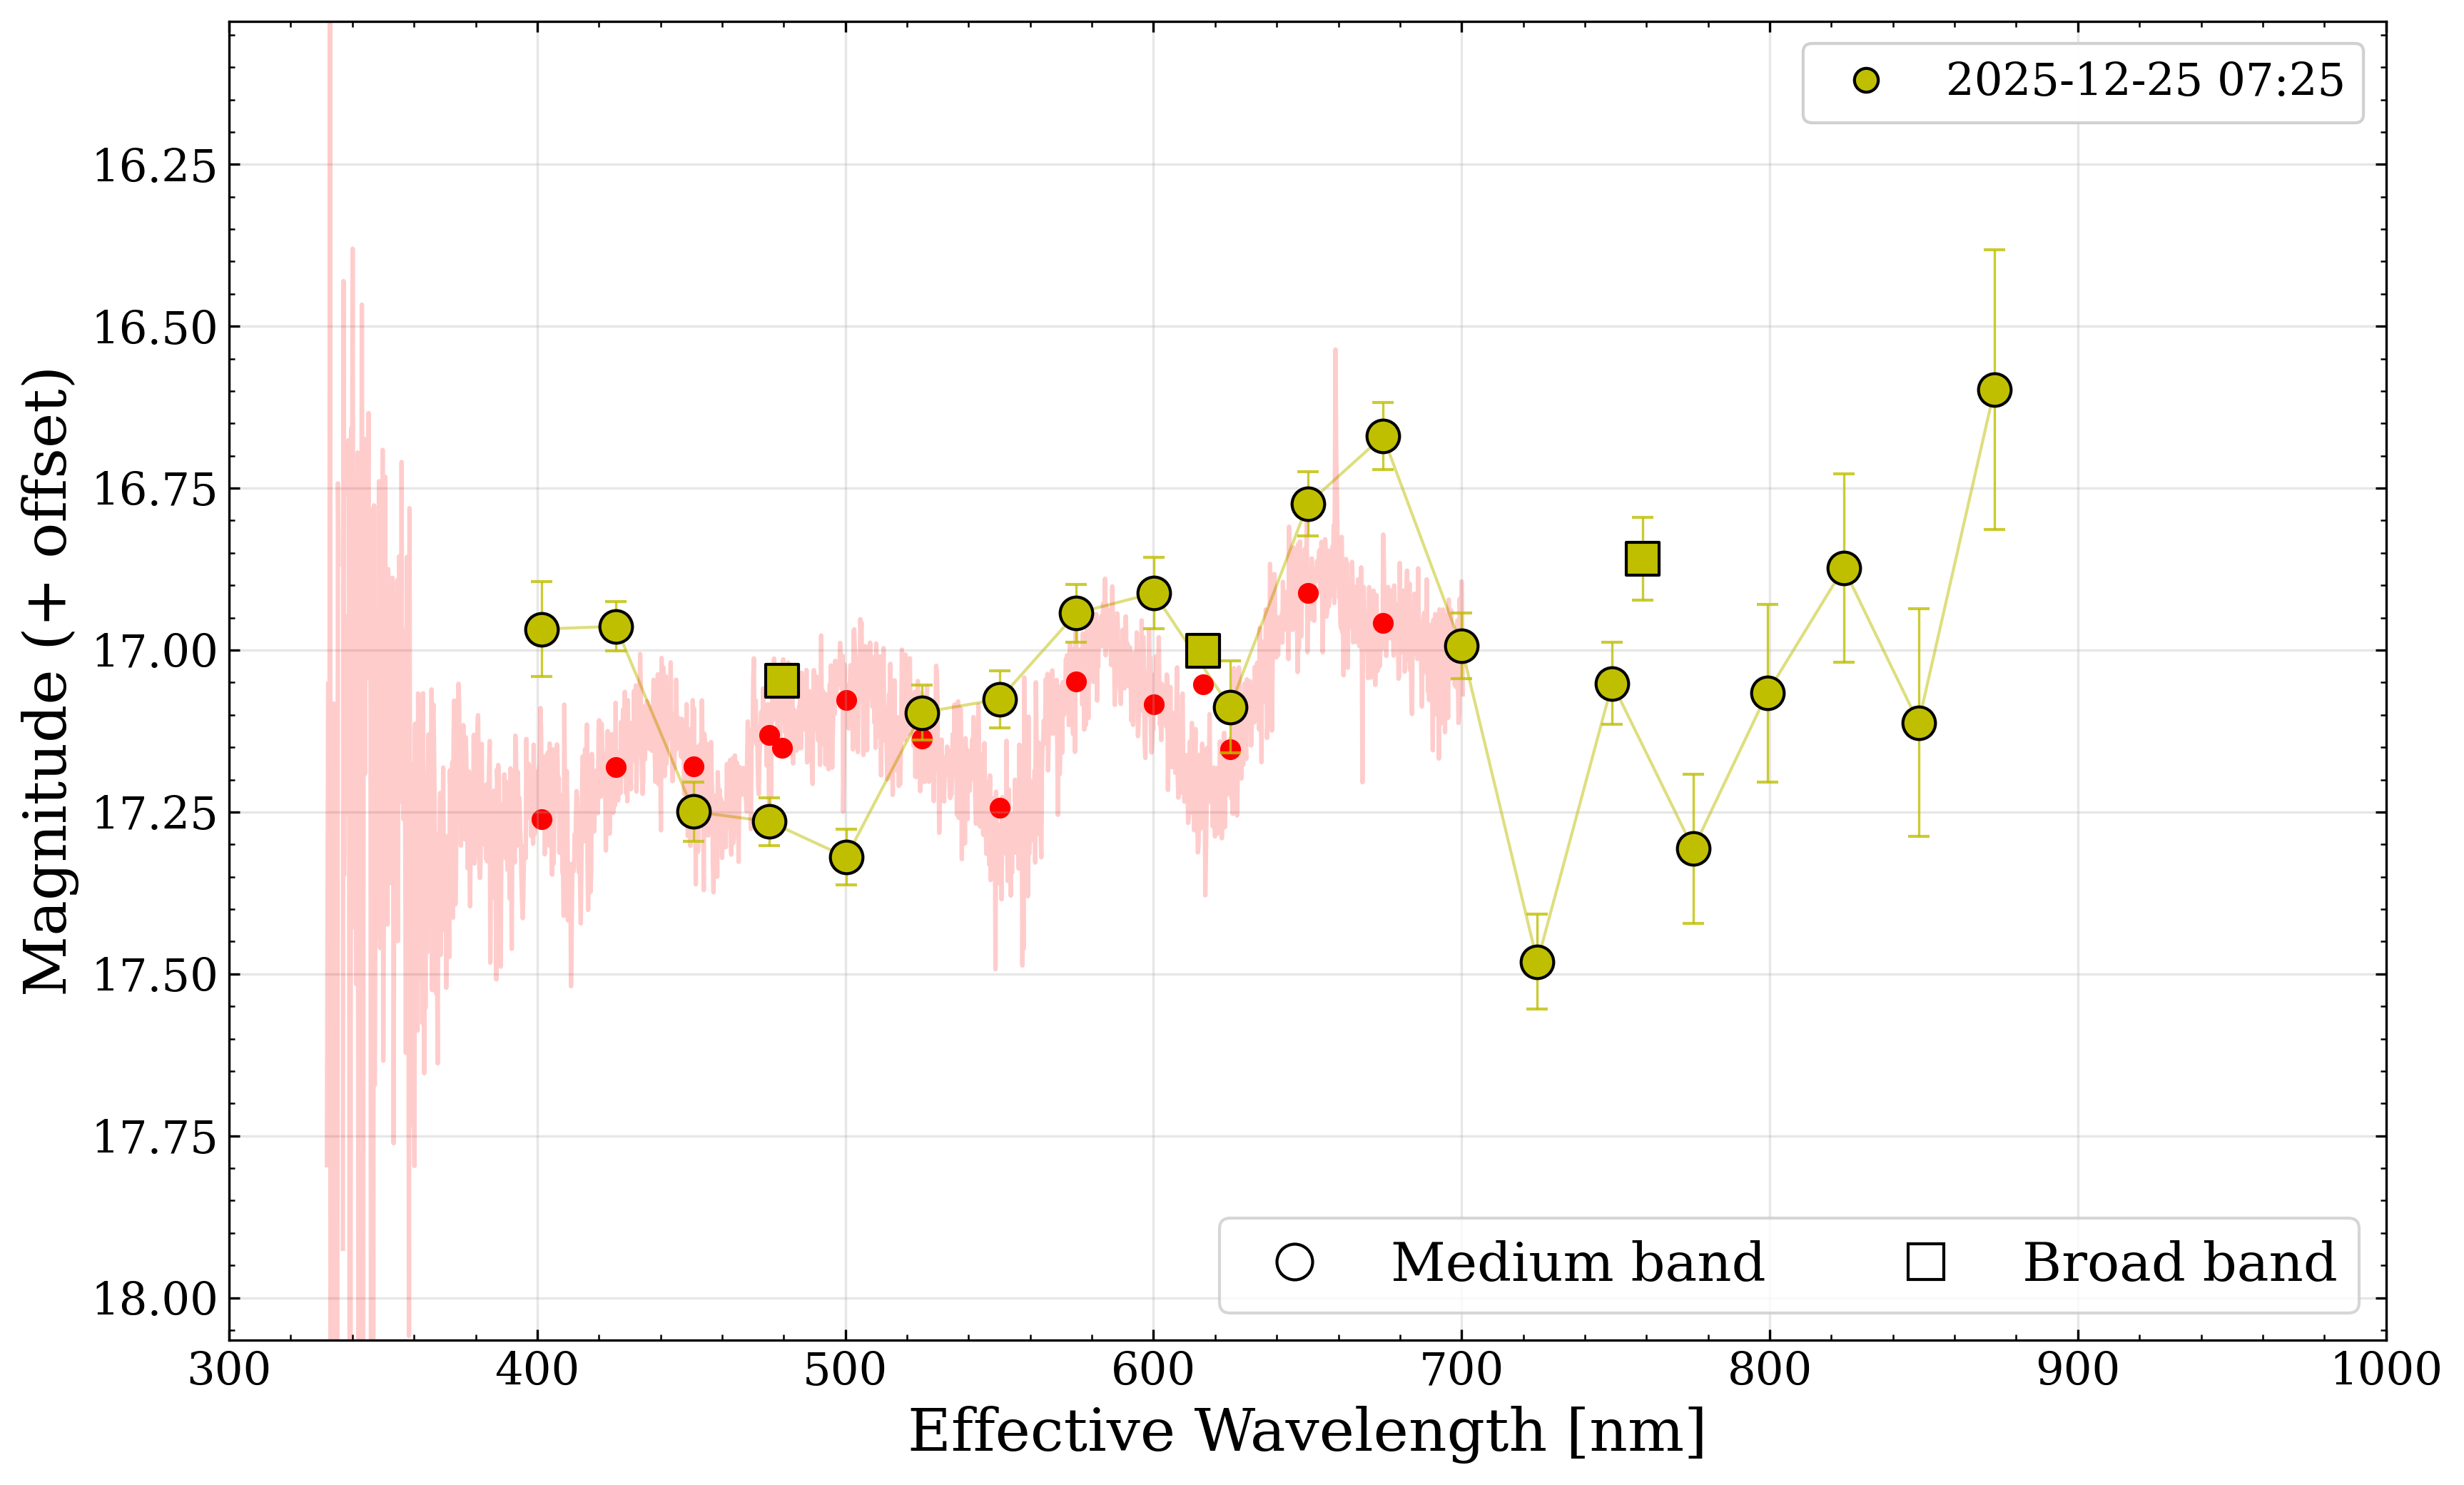

In [ ]:
fig_photspec

In [8]:
# Compare with Tractor photometry
from bridge.alertmonitor import AlertChecker
alertchecker = AlertChecker()

GWPortalClient: API connection successful.


Loading host galaxy catalog from /home/hhchoi1022/.bridge/regalade_light.fits ...
Catalog loaded with 79880104 sources.
Building sorted healpix index ...
Sorted healpix index built.


In [9]:
alert_instance.match_host(alertchecker.hostgalaxycatalog,
                            search_radius_arcsec = 600,
                            max_dell = 2.5,
                            return_all = False,
                            plot = True,
                            save_path = None)
processor = AlertProcessor()
processor.target_images = target_imglist_first

GWPortalClient: API connection successful.


In [10]:
processor.tractor_photometry(alert_instance)

Tractor photometry... [1-1/1]:   0%|          | 0/1 [00:00<?, ?it/s]

ID: AT2025aico_20251225_072513
Tract7DT working directory:  /home/hhchoi1022/tract7dt/AT2025aico_20251225_072513


Merging catalogs: 100%|██████████| 22/22 [00:00<00:00, 172.90it/s]
Constructing input catalogs...: 23it [00:00, 31.75it/s]


Input images and catalogs saved to:  /home/hhchoi1022/tract7dt/AT2025aico_20251225_072513/input_images.txt /home/hhchoi1022/tract7dt/AT2025aico_20251225_072513/input_catalogs.csv
No reference catalog is found in /lyman/data1/factory/ref_cat. Searching catalog from SkyCatalogUtility
Configuration saved to /home/hhchoi1022/tract7dt/AT2025aico_20251225_072513/configuration.yaml
Running tract7dt...
INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
         

2026-06-12 17:04:33,958 | tract7dt.cli | INFO | Config snapshot saved: /home/hhchoi1022/tract7dt/AT2025aico_20251225_072513/config_used_20260612_170433.yaml
2026-06-12 17:04:33,958 | tract7dt.pipeline | INFO | Warnings are suppressed (logging.ignore_warnings=true).
2026-06-12 17:04:33,958 | tract7dt.pipeline | INFO | Starting load inputs + validation...
2026-06-12 17:04:33,958 | tract7dt.pipeline | INFO | Config path: /home/hhchoi1022/tract7dt/AT2025aico_20251225_072513/configuration.yaml
2026-06-12 17:04:33,958 | tract7dt.pipeline | INFO | Input catalog path: /home/hhchoi1022/tract7dt/AT2025aico_20251225_072513/input_catalogs.csv
2026-06-12 17:04:33,958 | tract7dt.pipeline | INFO | GaiaXP synphot path: /lyman/data1/factory/ref_cat/gaiaxp_dr3_synphot_AT2025aico.csv
2026-06-12 17:04:34,016 | tract7dt.pipeline | INFO | 7DT frames to stack: 23 (list=/home/hhchoi1022/tract7dt/AT2025aico_20251225_072513/input_images.txt)
2026-06-12 17:04:34,017 | tract7dt.pipeline | INFO | Preparing image a

Catalog saved to /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT08/m850/coadd_scaled_subbkg_7DT08_20251225_072410_AT2025aico_m850_1x1_100.0s_0002.com.fits.tract7dtcat
Catalog saved to /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT08/m425/coadd_scaled_subbkg_7DT08_20251225_072747_AT2025aico_m425_1x1_100.0s_0001.com.fits.tract7dtcat
Catalog saved to /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT03/m475/coadd_scaled_subbkg_7DT03_20251225_072604_AT2025aico_m475_1x1_100.0s_0000.com.fits.tract7dtcat
Catalog saved to /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT03/m450/coadd_scaled_subbkg_7DT03_20251225_072042_AT2025aico_m450_1x1_100.0s_0000.com.fits.tract7dtcat
Catalog saved to /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/AT2025aico/7DT09/m500/coadd_scaled_subbkg_7DT09_20251225_072420_AT2025aico_m500_1x1_100.0s_0002.com.fits.tract7dtcat
Catalog saved to /home/hhchoi1

Tractor photometry... [1-1/1]: 100%|██████████| 1/1 [17:42<00:00, 1062.16s/it]

1/1 processed in batch
TOTAL: 1/1 processed


[{'success': True,
  'result': PosixPath('/home/hhchoi1022/tract7dt/AT2025aico_20251225_072513/final_catalog_with_fit.csv'),
  'error': None,
  'function': 'tractor_photometry'}]

In [13]:
target_catset_tractor = dbrowser.search('*.tract7dtcat', return_type = 'catalog')

[INFO] Found 23 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/AT2025aico/*/*/*.tract7dtcat'


Loading Catalogs: 100%|██████████| 23/23 [00:00<00:00, 25.11it/s]


In [20]:
target_catset_tractor.catalogs[0].select_sources?

Signature:
target_catset_tractor.catalogs[0].select_sources(
    x,
    y,
    unit='coord',
    matching_radius=5.0,
    x_key='X_WORLD',
    y_key='Y_WORLD',
)
Docstring: Select all sources within matching_radius.
File:      ~/code/ezphot/ezphot/dataobjects/catalog.py
Type:      method

Merging catalogs: 100%|██████████| 22/22 [00:00<00:00, 207.85it/s]


Matched 1 sources out of 1 input positions.
[WARNING] MAGERR_APER_2 not found in table. Ignoring flux error component.
[WARNING] ZPERR_APER_2 not found in table. Ignoring zp error component.
[WARNING] UL5SKY_APER_2 not found in table. Ignoring depth plot.


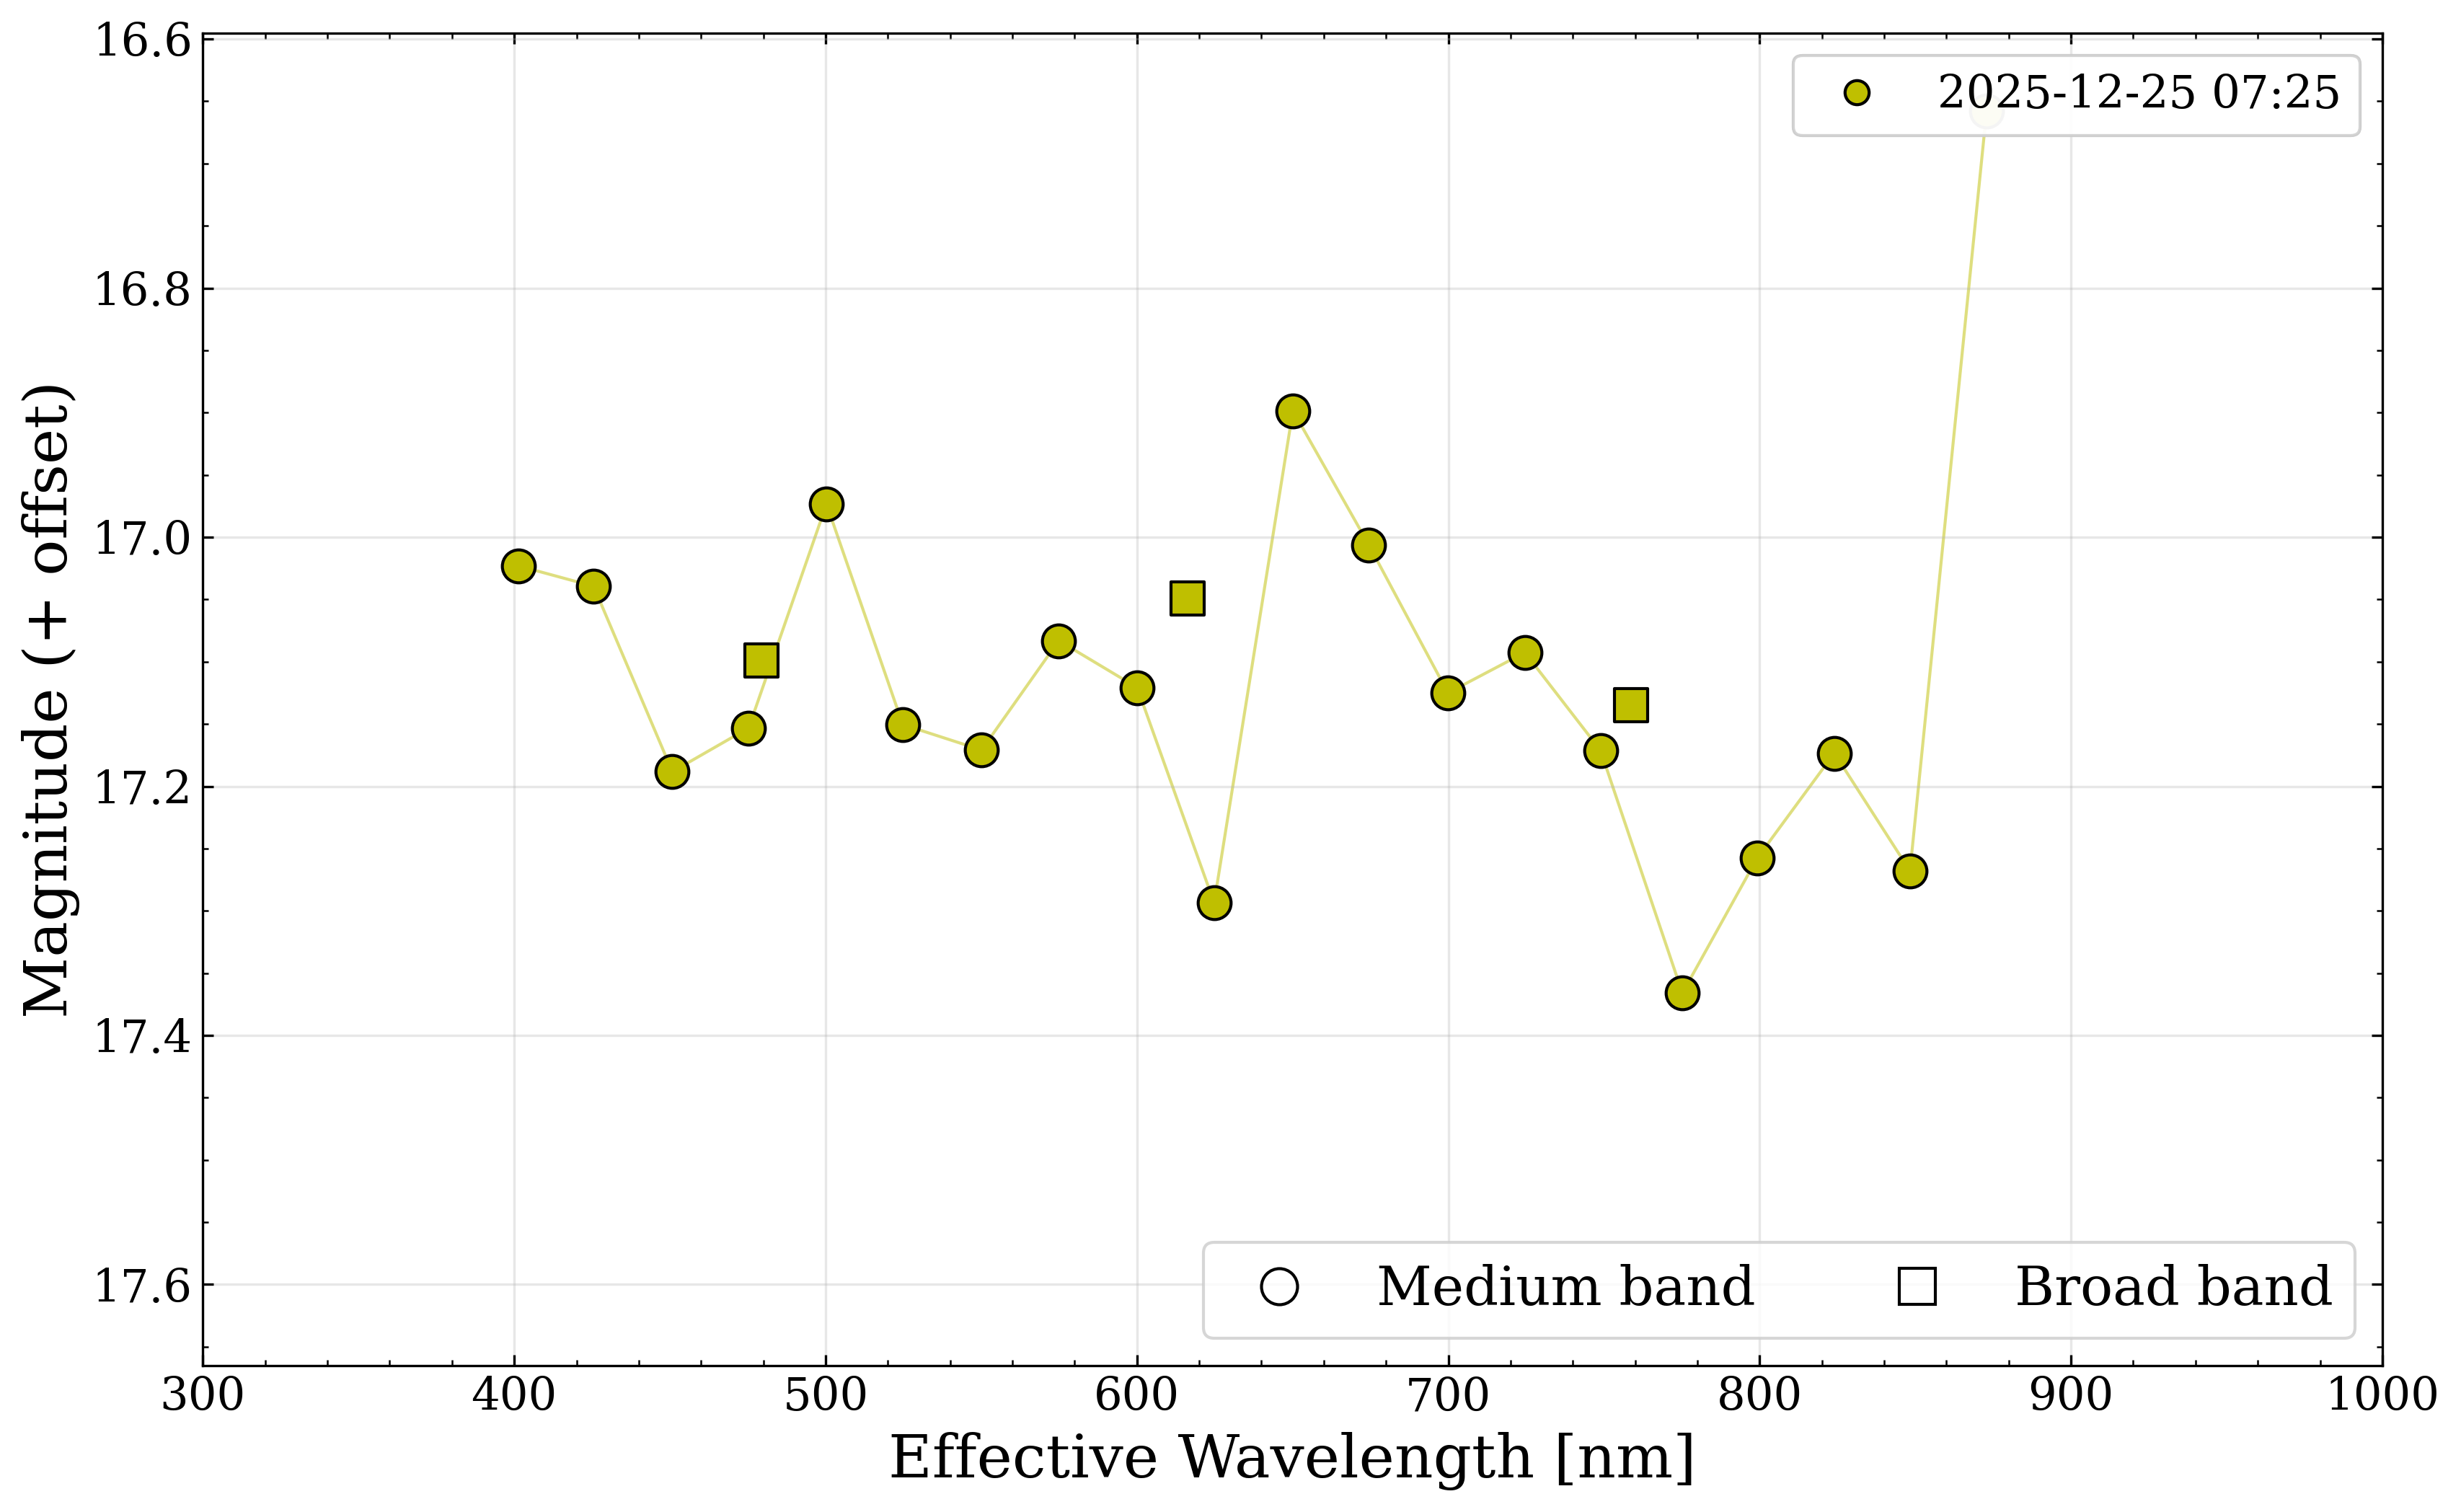

In [23]:
%matplotlib inline
from ezphot.dataobjects import PhotometricSpectrum
photspec_tractor = PhotometricSpectrum(target_catset_tractor)
fig_photspec, _, ax_photspec, tbl_photspec = photspec_tractor.plot(target_ra, target_dec, flux_key = 'MAG_TRACT7DT', matching_radius_arcsec = 1)
fig_photspec = fig_photspec['2025-12-25 07:25']
ax_photspec = ax_photspec['2025-12-25 07:25']

In [25]:
# Load spectrum from TNS
from astropy.io import ascii
tns_spectra['obsdate'] = Time(tns_spectra['jd'], format = 'jd').isot
tns_spectra['mjd'] = Time(tns_spectra['jd'], format = 'jd').mjd
target_spec_row = tns_spectra[0]
spec_data = ascii.read(target_spec_row['ascii_file'])
from ezphot.dataobjects import Spectrum
spec = Spectrum(target_spec_row['ascii_file'])
spec_synphot = spec.synphot()
import numpy as np
ax_photspec.plot(spec.wavelength/10, np.array(spec.ab.flux), c = 'r', label = 'TNS', alpha = 0.2)
for filter, synphot_dict in spec_synphot[0].items():
    if filter in tbl_photspec['filter']:
        ax_photspec.scatter(synphot_dict['wl_pivot'].value, synphot_dict['mag'], c = 'r', label = 'TNS')

ASCII file read: /home/hhchoi1022/bridge/alert/tns/2025aico/TNS/tns_2025aico_2025-12-25_08-03-14_SOAR_Goodman_None.txt
Flux unit estimated from data: FLAMB
Wavelength unit estimated from data: AA


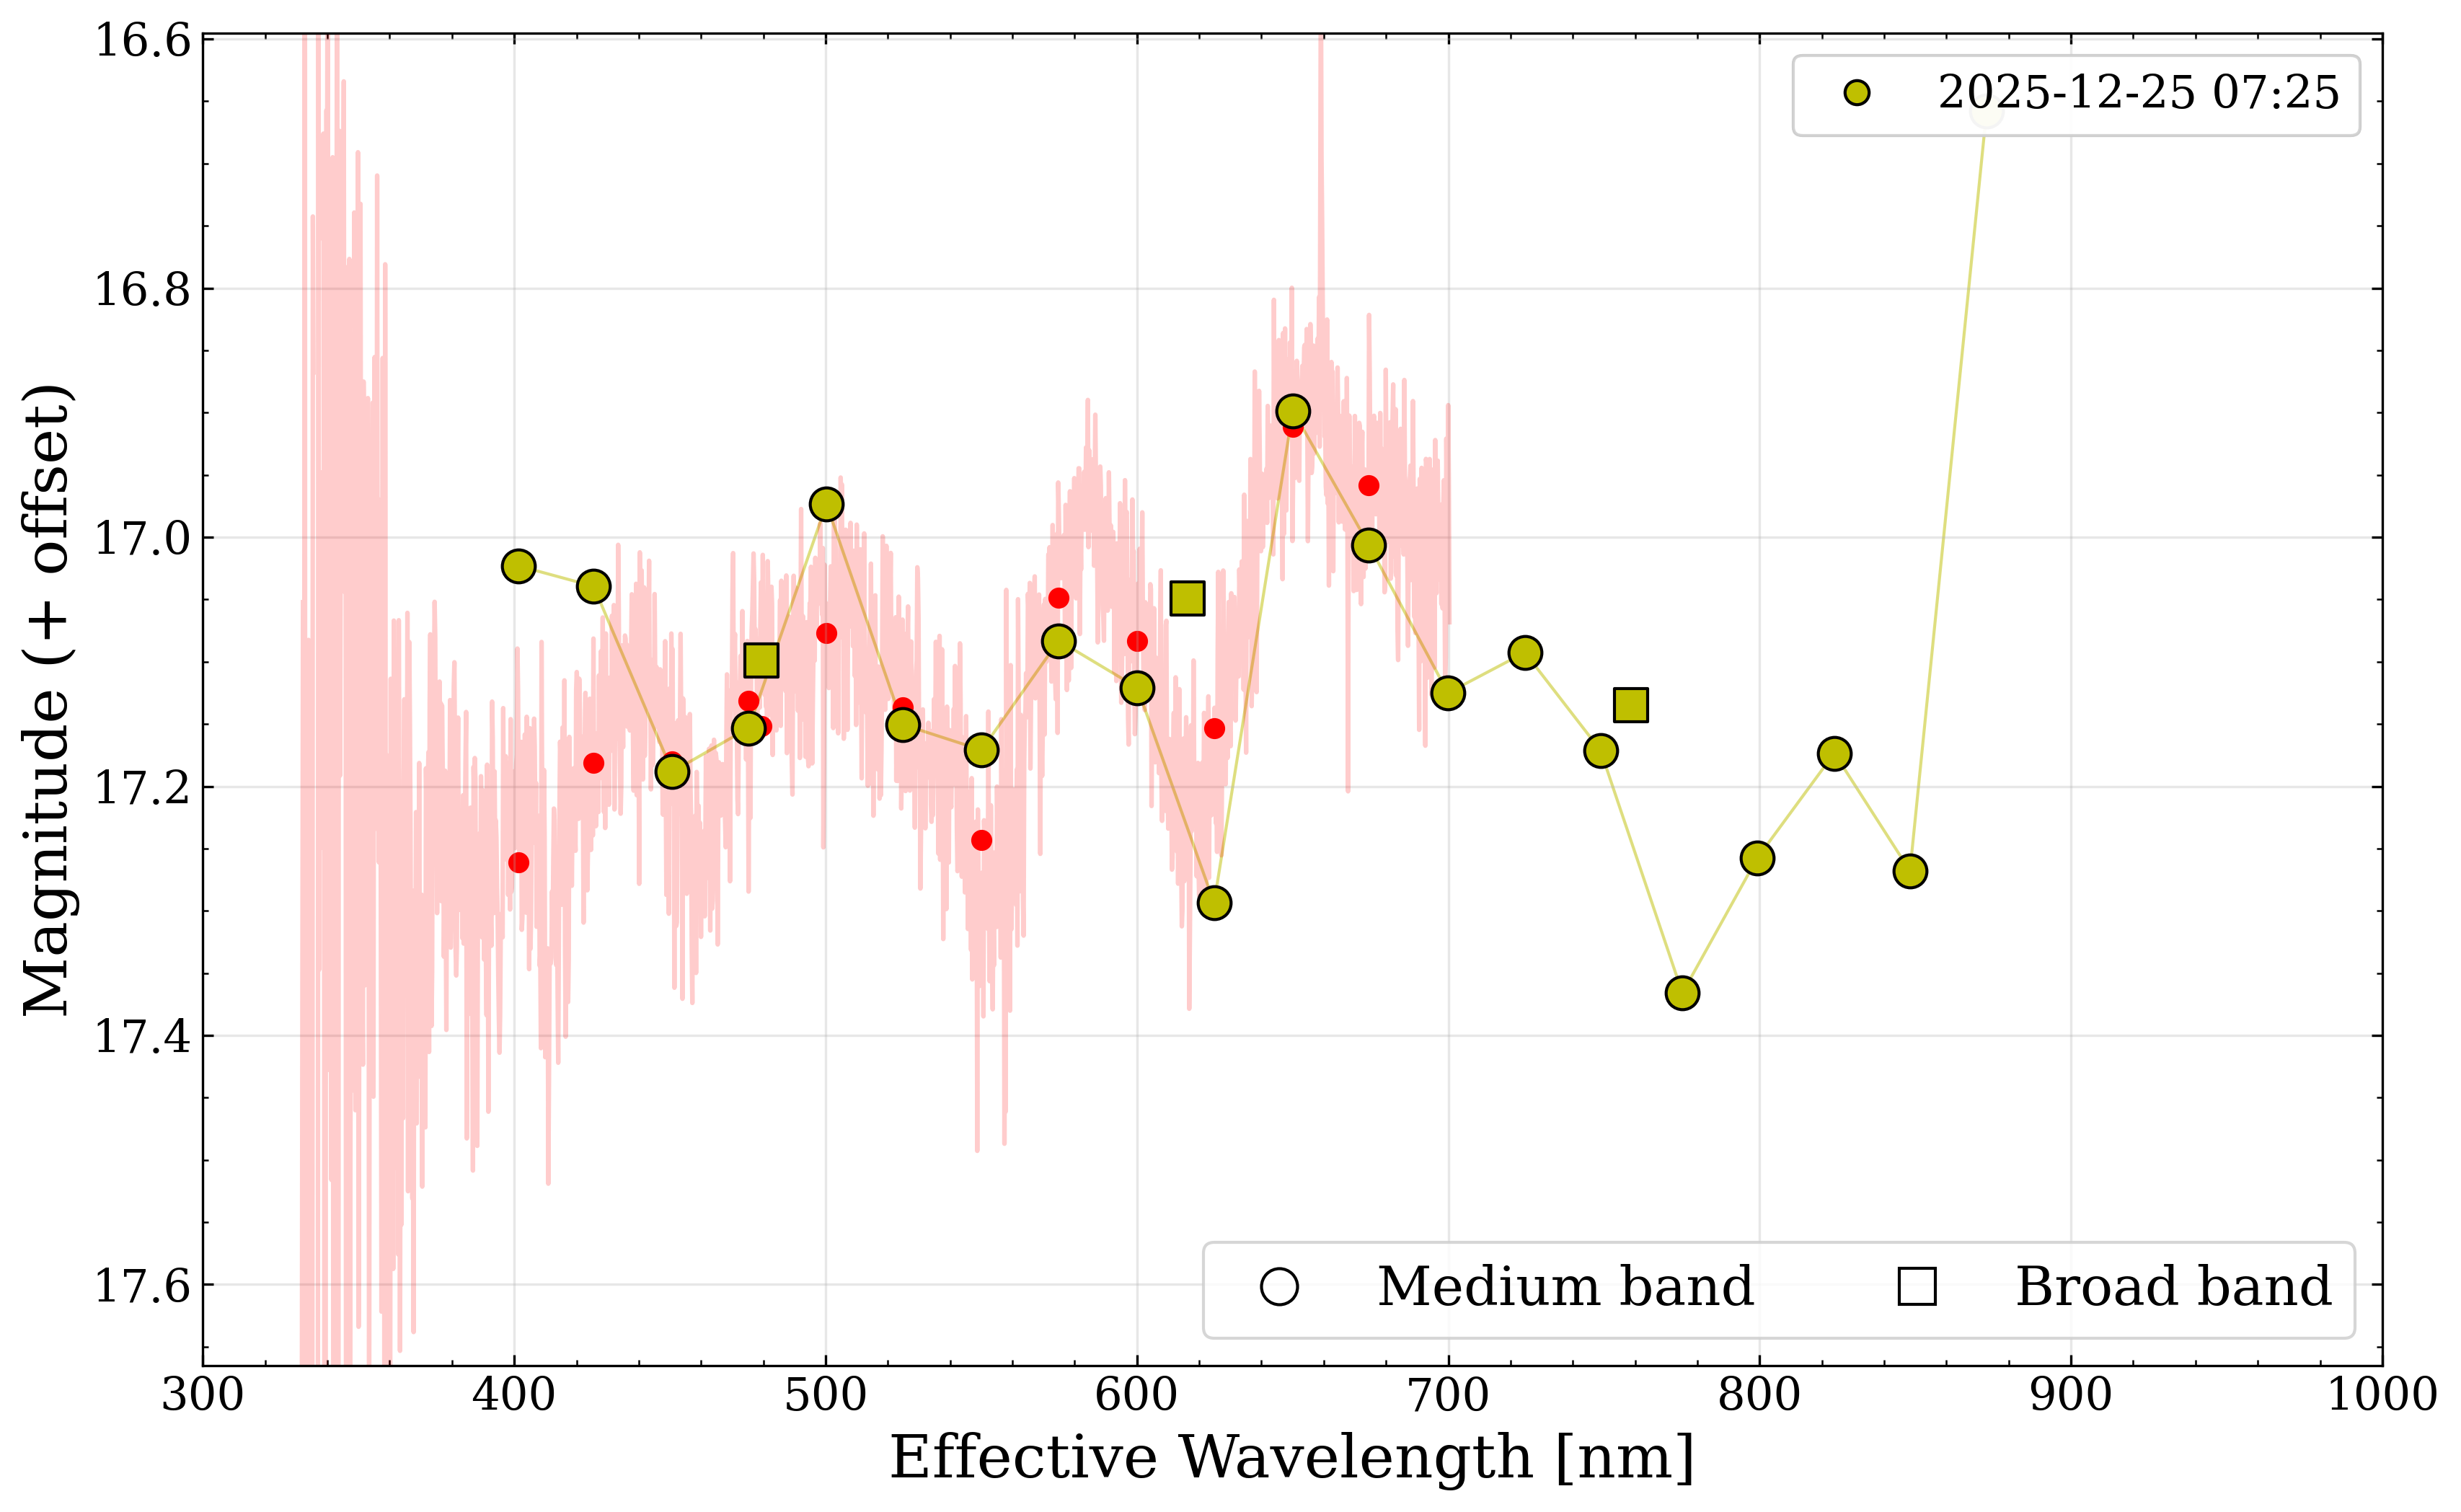

In [26]:
fig_photspec

In [49]:
medium_catlist = [cat for cat in target_catset_tractor.catalogs if not cat.info.filter in ['g', 'r', 'i']]

Merging catalogs: 100%|██████████| 19/19 [00:00<00:00, 197.54it/s]


Matched 1 sources out of 1 input positions.
[WARNING] MAGERR_APER_2 not found in table. Ignoring flux error component.
[WARNING] ZPERR_APER_2 not found in table. Ignoring zp error component.
[WARNING] UL5SKY_APER_2 not found in table. Ignoring depth plot.


Merging catalogs: 100%|██████████| 19/19 [00:00<00:00, 200.53it/s]


Matched 1 sources out of 1 input positions.
Default parameters.json is loaded. Please provide parameters by modifying attributes of the Parameters class.


Loading templates...: ██████████


Running optimization for spectrum file: /home/hhchoi1022/bridge/results/AT2025aico/AT2025aico_20251225_072521_tract7dt_CL_spec.csv with 7DT resolution
NGSF started
Runtime:  54.14s 


True

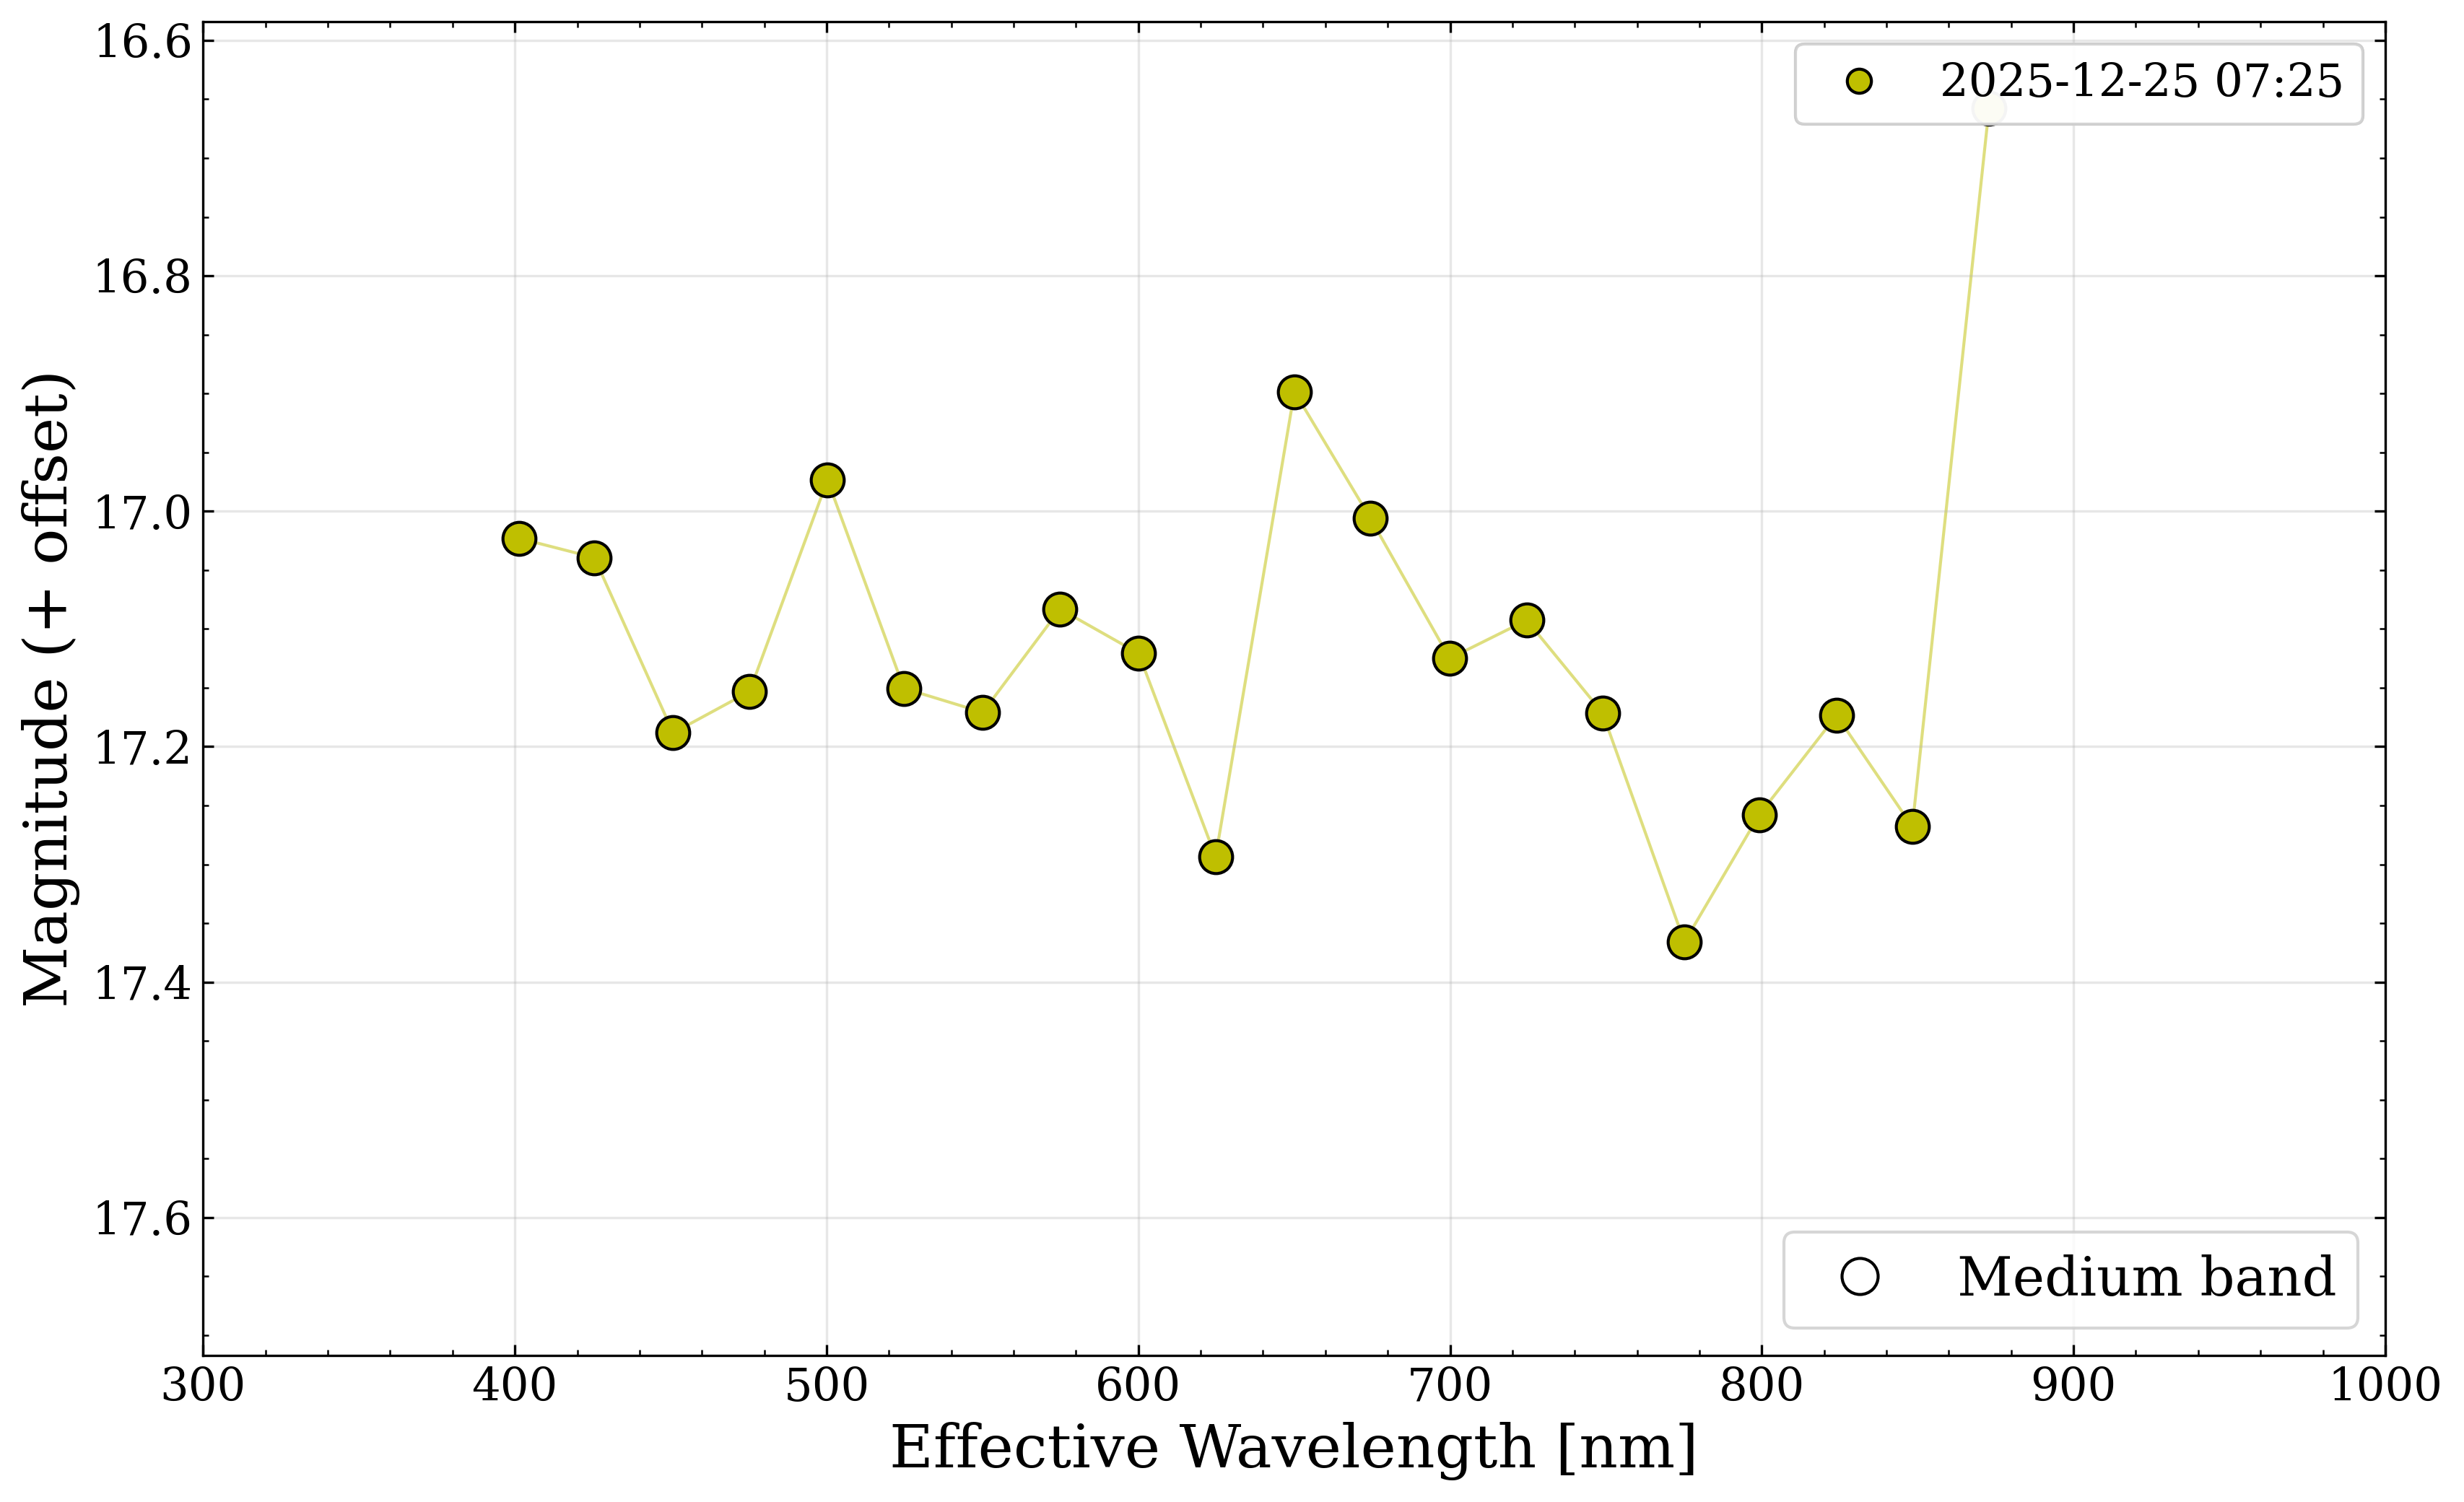

In [53]:
from ezphot.dataobjects import CatalogSet
catset_new = CatalogSet(medium_catlist)
photspec_new = PhotometricSpectrum(catset_new)
fig_photspec, _, ax_photspec, tbl_photspec = photspec_new.plot(target_ra, target_dec, flux_key = 'MAG_TRACT7DT', matching_radius_arcsec = 1)
fig_photspec = fig_photspec['2025-12-25 07:25']
ax_photspec = ax_photspec['2025-12-25 07:25']
alertchecker.config.matching_radius_arcsec = 1
alertchecker.classify_alert(alert_instance, catalog_set = catset_new, catalog_type = 'tract7dt')